# Эквивалентная сфера и альтернативные модели сердца: физиология, 4D-динамика и электрический отклик

**Статус:** методическая постановка этапа разработки. В этом ноутбуке определены варианты замещения и программа их сравнения. Численные преимущества конкретного варианта и физиологическая точность эквивалентной сферы пока не установлены.

Главный вопрос состоит в том, какое приближение одновременно сохраняет заданные физиологические характеристики сердца и электрический отклик с достаточной точностью при минимально необходимом наборе индивидуальных входов. Сравниваются геометрические представления и законы их изменения; сфера является одним из кандидатов. Сохранение объёма само по себе не обеспечивает сохранения сигнала, а хорошее совпадение сигнала не доказывает верной физиологической интерпретации.

Сначала изложен набор методов, сформулированный независимо от просмотра работ РФФИ и Тихомирова. В разделе 16 выполнено сопоставление с этими источниками и историческим кодом. Раздел 17 фиксирует уточнённую автором совместную постановку, конкурирующие гипотезы и основания индивидуализации по механике и внешним данным. Все специально построенные рисунки этого ноутбука являются схемами или синтетическими математическими примерами. Они не представляют результаты индивидуальной КТ, FEM или измерения реокардиомонитора.

## 1. Предмет замещения и смысл эквивалентности

Пусть $H_t$ — область, выделенная маской сердца в момент или фазу $t$, а
$$
S_t=\{\mathbf x:\|\mathbf x-\mathbf c_t\|\le r_t\}
$$
— замещающий шар. Его поверхность является сферой; далее выражение «эквивалентная сфера» используется как принятое обозначение объёмной модели. Здесь $\mathbf c_t=(c_{x,t},c_{y,t},c_{z,t})$ — центр, $r_t$ — радиус. До расчёта фиксируются единицы, анатомические направления осей и преобразование координат изображения в физические координаты.

Следует различать три цели.

1. **Геометрическое замещение:** сохранить выбранные характеристики маски, например объём и центр объёма.
2. **Электрическое замещение:** приблизить импедансы и их изменения на заранее определённом наборе электродных сборок и состояний тканей.
3. **Физиологическая интерпретация:** установить, какой независимо определённой функции сердца соответствуют восстановленные параметры сферы.

Успех первого этапа не подтверждает второй; успех второго не завершает третий. Геометрически определённый центр имеет анатомический смысл относительно выбранной маски. Центр, подобранный по импедансу, первоначально имеет смысл параметра эффективного электрического включения.

В действующей статической модели используется маска сердца целиком с однородным эффективным удельным сопротивлением смеси крови и миокарда. Из этого допущения не следует, какова доля крови. В 4D-ветке могут рассматриваться другие области: целое сердце, полости отдельных камер, объединение камер, остаточная область после вычитания. Они должны иметь отдельные определения и не подменять друг друга.

**Изменение объёма целой сердечной маски, изменение объёма полости левого желудочка и ударный объём — разные исследовательские величины.** Переход между ними требует обоснованной анатомической модели, временной привязки и оценки ошибок.

## 2. Статическое замещение: объём и центр объёма

Для маски $H$ определим
$$
V_H=\int_H dV,\qquad
\mathbf c_H=\frac{1}{V_H}\int_H\mathbf x\,dV,\qquad
r_V=\left(\frac{3V_H}{4\pi}\right)^{1/3}.
$$

Здесь $V_H$ — объём выделенной области; $\mathbf c_H$ — её геометрический центр объёма при равномерном распределении веса по объёму; $r_V$ — радиус шара такого же объёма. Это определение сохраняет нулевой и первый пространственные моменты области. Оно не сохраняет вытянутость, ориентацию и локальные особенности поверхности.

Для объёмных элементов с центрами $\mathbf x_i$ и объёмами $v_i$
$$
V_H=\sum_i v_i,\qquad
\mathbf c_H=\frac{\sum_i v_i\mathbf x_i}{\sum_i v_i}.
$$
Для полных вокселей одной серии объёмы одинаковы; для тетраэдров они обычно различаются. Усреднение вершин поверхностной сетки без весов не вычисляет центр объёма и зависит от распределения вершин.

**Метод Г1:** центр $\mathbf c_H$, радиус $r_V$. Используется как прозрачный контрольный вариант для всех сборок, без предположения о его преимуществе перед другими представлениями. Его параметры определяются по геометрии и не подгоняются под электрический результат.

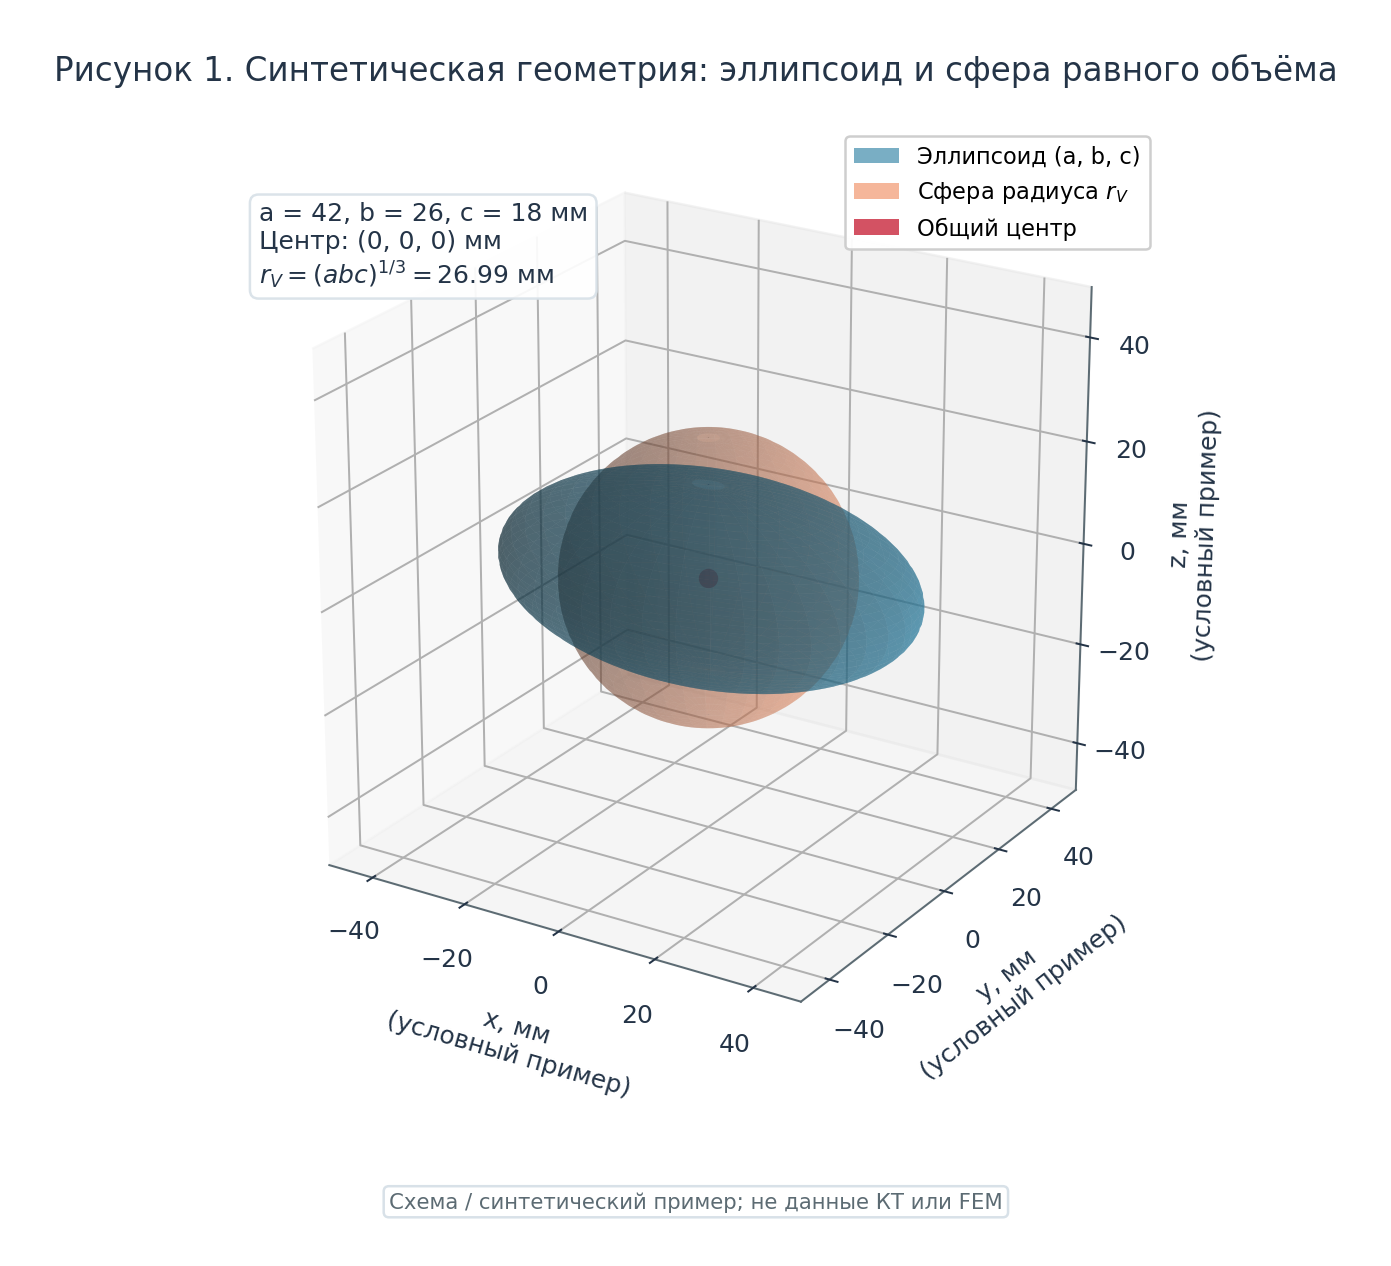

*Рисунок 1. Геометрический смысл замещения. На синтетическом примере вытянутой области показана сфера равного объёма с общим центром. Совпадение объёма оставляет области, принадлежащие только исходной форме или только сфере. Именно в этих областях меняется распределение электрических свойств при замещении. Изображение не показывает анатомию испытуемого.*

## 3. Альтернативные геометрические критерии

| Метод | Определение | Сохраняемое свойство | Ограничение |
|---|---|---|---|
| Г1. Объём и центр объёма | Аналитические формулы раздела 2 | Объём и первый пространственный момент | Не сохраняется форма |
| Г2. Второй нормированный момент | Общий центр; радиус по среднеквадратичному расстоянию до центра | Среднеквадратичная пространственная протяжённость | Объём обычно изменяется |
| Г3. Подгонка поверхности | Минимум ошибки расстояния с весами по площади поверхности | Близость исходной границы к сфере по выбранной мере | Результат зависит от критерия и качества поверхности |
| Г4. Максимальное перекрытие | Максимум отношения пересечения областей к их объединению | Объёмное совпадение | Сохранение объёма и центра требует отдельных ограничений |

Для Г2 вводится
$$
m_2=\frac{1}{V_H}\int_H\|\mathbf x-\mathbf c_H\|^2dV,\qquad
r_2=\sqrt{\frac{5m_2}{3}}.
$$
Здесь $m_2$ — второй нормированный центральный момент, имеющий размерность длины в квадрате. Множитель $5/3$ следует из значения $m_2=3r^2/5$ для однородного шара. Сохраняется нормированный момент, а не одновременно момент, объём и форма.

Для Г3 возможен критерий
$$
E_{\partial}(\mathbf c,r)=
\frac{1}{A_H}\int_{\partial H}
(\|\mathbf x-\mathbf c\|-r)^2dA,
$$
где $A_H$ — площадь поверхности. При фиксированном центре оптимальный радиус равен среднему расстоянию до поверхности с весами по площади. При изменении центра возникает задача оптимизации; её решение и устойчивость нужно проверять. На треугольной сетке необходимы площадочные веса или квадратура.

Для Г4 используется
$$
J(H,S)=\frac{|H\cap S|}{|H\cup S|}.
$$
Вертикальные черты в числителе и знаменателе обозначают объёмы соответствующих областей. Можно искать максимум $J$ при фиксированном $r=r_V$, изменяя только центр. Это отделяет сохранение объёма от выбора положения. Без такого ограничения оптимальный радиус имеет другой смысл.

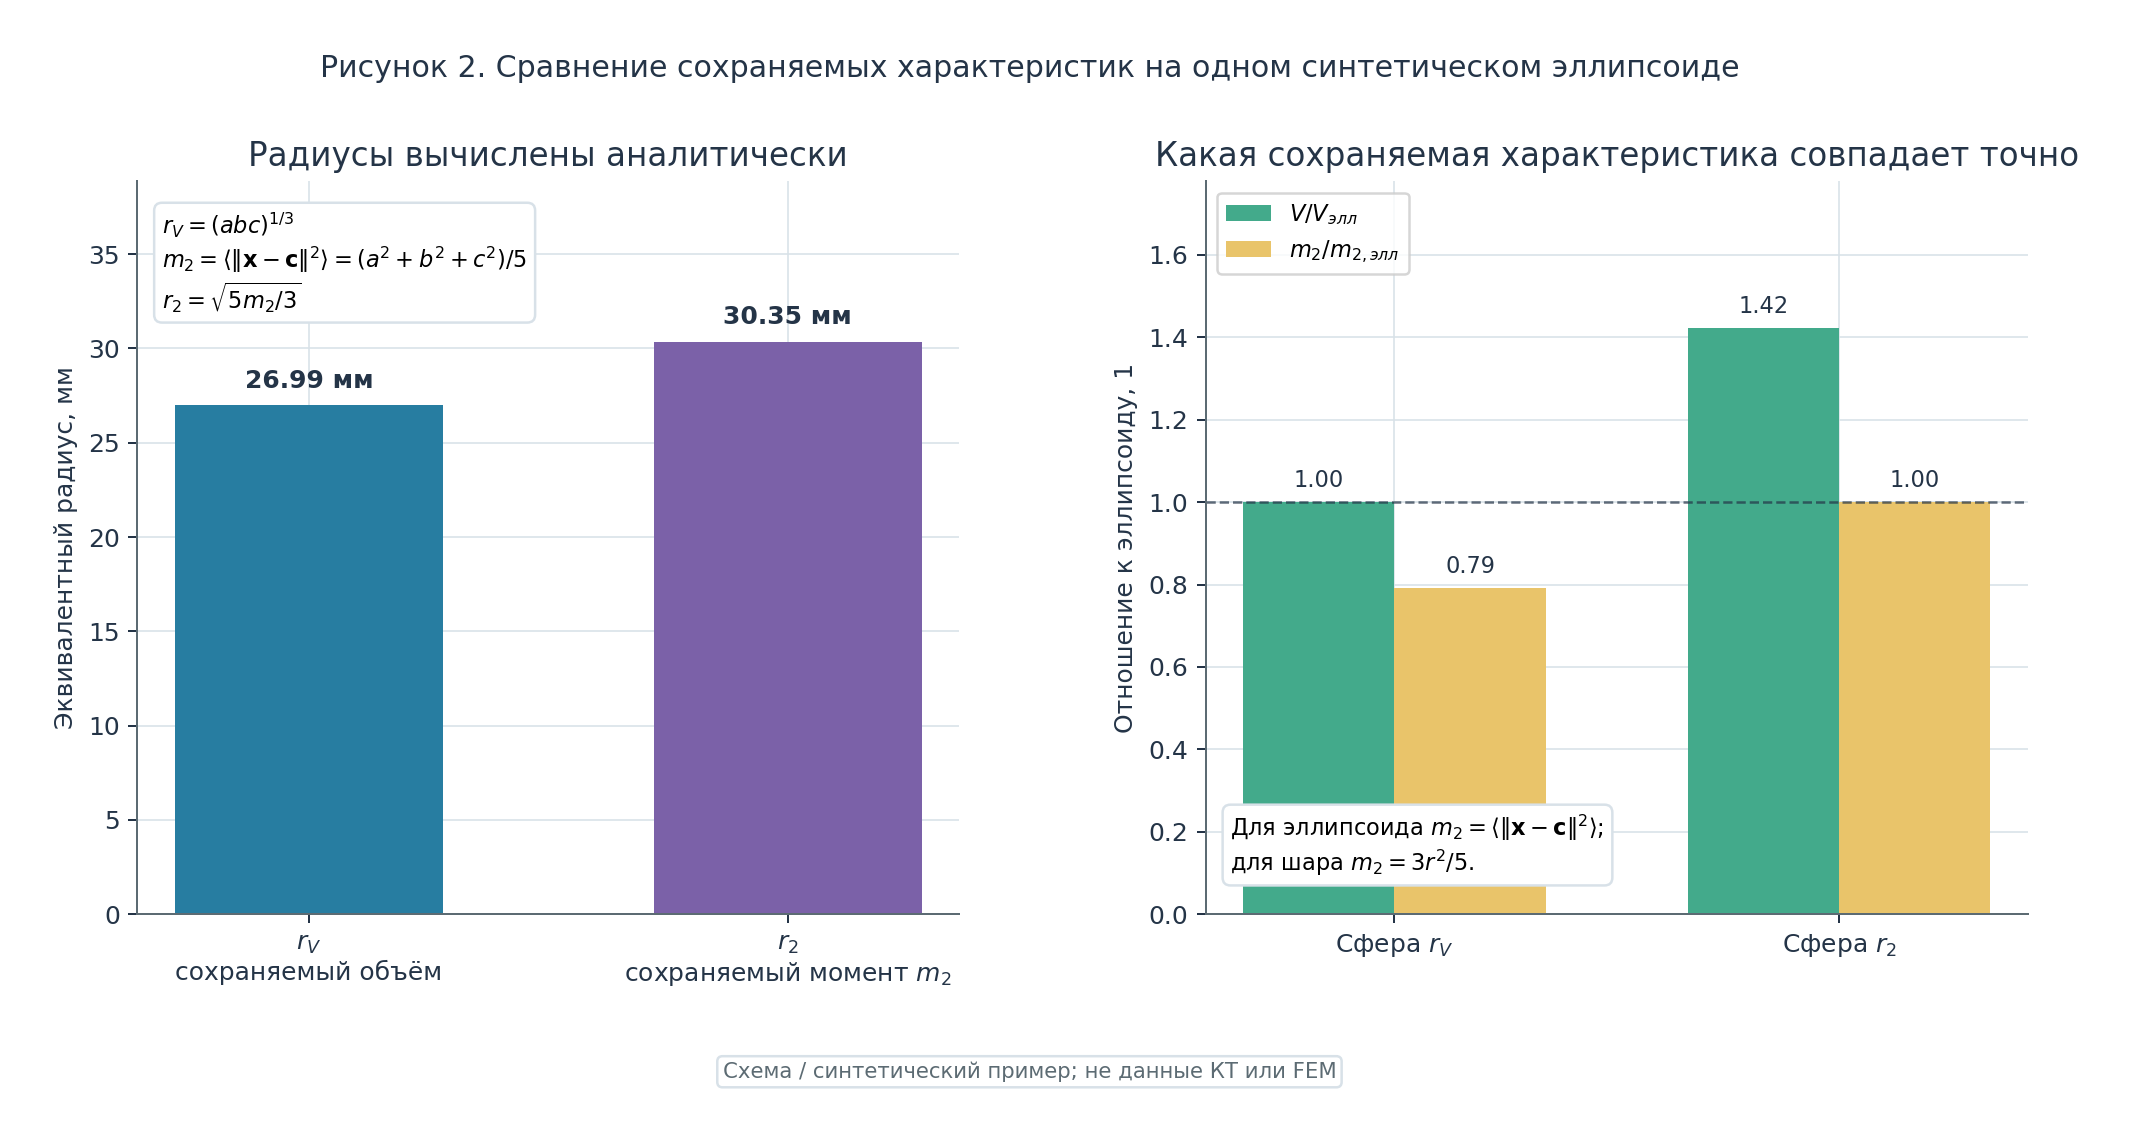

*Рисунок 2. Зависимость радиуса от определения эквивалентности на синтетической геометрии. Радиус по объёму и радиус по второму нормированному моменту могут различаться без вычислительной ошибки: они сохраняют разные свойства. Сравнение необходимо для оценки зависимости будущих результатов от самого определения сферы.*

## 4. Электрическое определение сферы

Пусть $Z_{m,s}(H)$ — передаточный импеданс исходной модели для сборки $m$ и состояния удельных сопротивлений $s$. Метод Э1 определяет общие координаты и радиус посредством минимизации
$$
E_Z(\theta)=\sum_{m,s}
\left|\frac{Z_{m,s}(S(\theta))-Z_{m,s}(H)}{a_{m,s}}\right|^2,
\qquad
\theta=(c_x,c_y,c_z,r).
$$
Здесь $a_{m,s}>0$ — заранее заданные масштабы нормировки с размерностью Ом. Они могут быть определены требованиями задачи или независимо оценённой неопределённостью, но их нельзя подбирать после просмотра ошибок на проверочных данных.

Совпадение исходных импедансов не обеспечивает совпадения чувствительностей. Для малых геометрических изменений $p$
$$
Z(p_0+\Delta p)=Z(p_0)+J_p\Delta p+O(\|\Delta p\|^2),
$$
где $J_p$ — строка или матрица производных. Две модели могут совпадать по первому слагаемому и различаться по второму.

**Метод Э2:** согласование импедансов и геометрических производных. Ошибки каждого типа сначала оцениваются раздельно. Если они объединяются в функционал, для них заранее задаются собственные масштабы и веса, чтобы не складывать величины разных размерностей без нормировки.

Подгоняется одна общая сфера для обучающего набора сборок. Та же сфера затем используется на других сборках и состояниях тканей. Отдельная подгонка под каждую сравниваемую сборку лишает такое сравнение общего объекта.

На первом этапе эффективное $\rho_H$ сердца одинаково в исходной и сферической моделях. Если его также подбирать, оно становится отдельным неизвестным параметром. Радиус не должен скрыто компенсировать ошибку $\rho_H$, контактов или геометрии других органов.

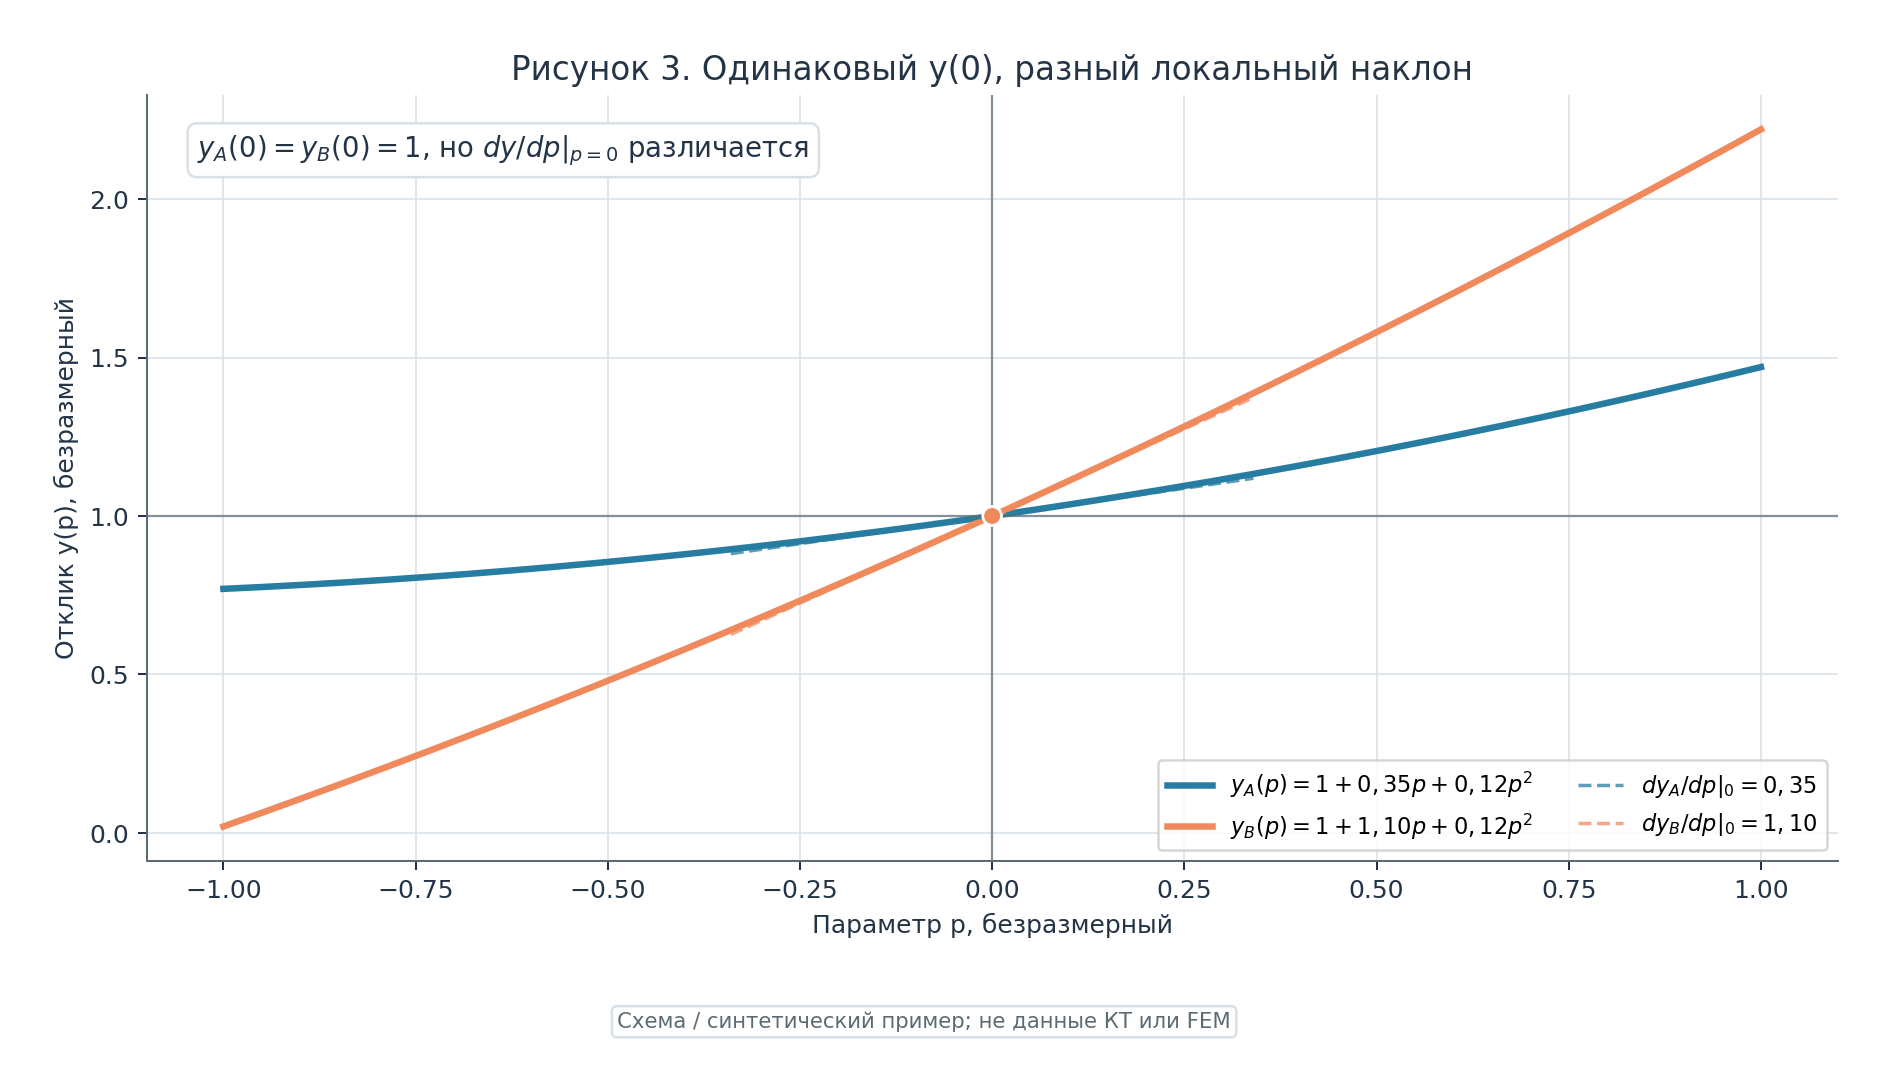

*Рисунок 3. Совпадение значения функции не означает совпадения производной. Показаны две специально заданные математические функции с общим значением в исходной точке и разными наклонами. Этот пример поясняет логическую причину отдельной проверки чувствительности; он не является решением электрической задачи.*

## 5. Варианты, использующие последовательность 4D-КТ

Временная последовательность масок позволяет рассчитать траектории геометрических показателей. До независимой проверки эти траектории описывают изменение сегментированных областей. Они могут содержать физическое движение, деформацию, особенности реконструкции и изменчивость сегментации.

Обозначим выбранный опорный кадр $t_0$, объём $V_t=|H_t|$ и центр объёма $\mathbf c_t$. Опорному кадру нельзя автоматически присваивать статус конечной диастолы. Использование фазовых процентов и их перевод в секунды требуют подтверждённой связи с соответствующим сердечным циклом.

| Метод | Параметры сферы | Назначение |
|---|---|---|
| Д1. Покадровое сохранение геометрических моментов | $\mathbf c^S_t=\mathbf c_t$, $r^S_t=(3V_t/4\pi)^{1/3}$ | Совместное перенесение объёма и положения по каждой маске |
| Д2. Только изменение объёма | $\mathbf c^S_t=\mathbf c_{t_0}$, радиус по $V_t$ | Контроль влияния изменения объёма при фиксированном центре |
| Д3. Только перемещение | $\mathbf c^S_t=\mathbf c_t$, $r^S_t=r_{t_0}$ | Контроль влияния положения при фиксированном объёме |
| Д4. Движение по регистрации масок | Перенос центра по заранее определённому преобразованию регистрации | Сопоставление перемещения всей формы с перемещением центра объёма |
| Д5. Совместная подгонка последовательности поверхностей | Центры и радиусы по геометрической ошибке с явным временным ограничением | Исследование устойчивости траекторий к неровностям отдельных масок |
| Д6. Согласование динамического электрического отклика | Общая для сборок траектория $\mathbf c^S_t,r^S_t$, подобранная по $\Delta Z$ | Проверка существования эффективной электрической траектории |

Д2 и Д3 являются контрольными вычислительными опытами. Они не предполагают, что в организме объём и положение изменяются независимо. Д1 объединяет оба наблюдаемых геометрических изменения, однако сохранение этих траекторий ещё не подтверждает сохранения $\Delta Z$.

Для любой выбранной базовой сферы возможен отдельный **вариант переноса приращений**:
$$
V^S_t=V^S_{t_0}+V_t-V_{t_0},\qquad
\mathbf c^S_t=\mathbf c^S_{t_0}+\mathbf c_t-\mathbf c_{t_0}.
$$
Радиус вычисляется из $V^S_t$, причём требуется $V^S_t>0$. Если исходная сфера уже сохраняет объём и центр опорной маски, этот вариант совпадает с Д1. При электрически подобранной базовой сфере он отличается от Д1: сохраняются приращения, но не обязательно абсолютные анатомические значения. Коэффициент передачи объёмного приращения, отличный от единицы, был бы дополнительным калибруемым параметром и требовал бы отдельной проверки.

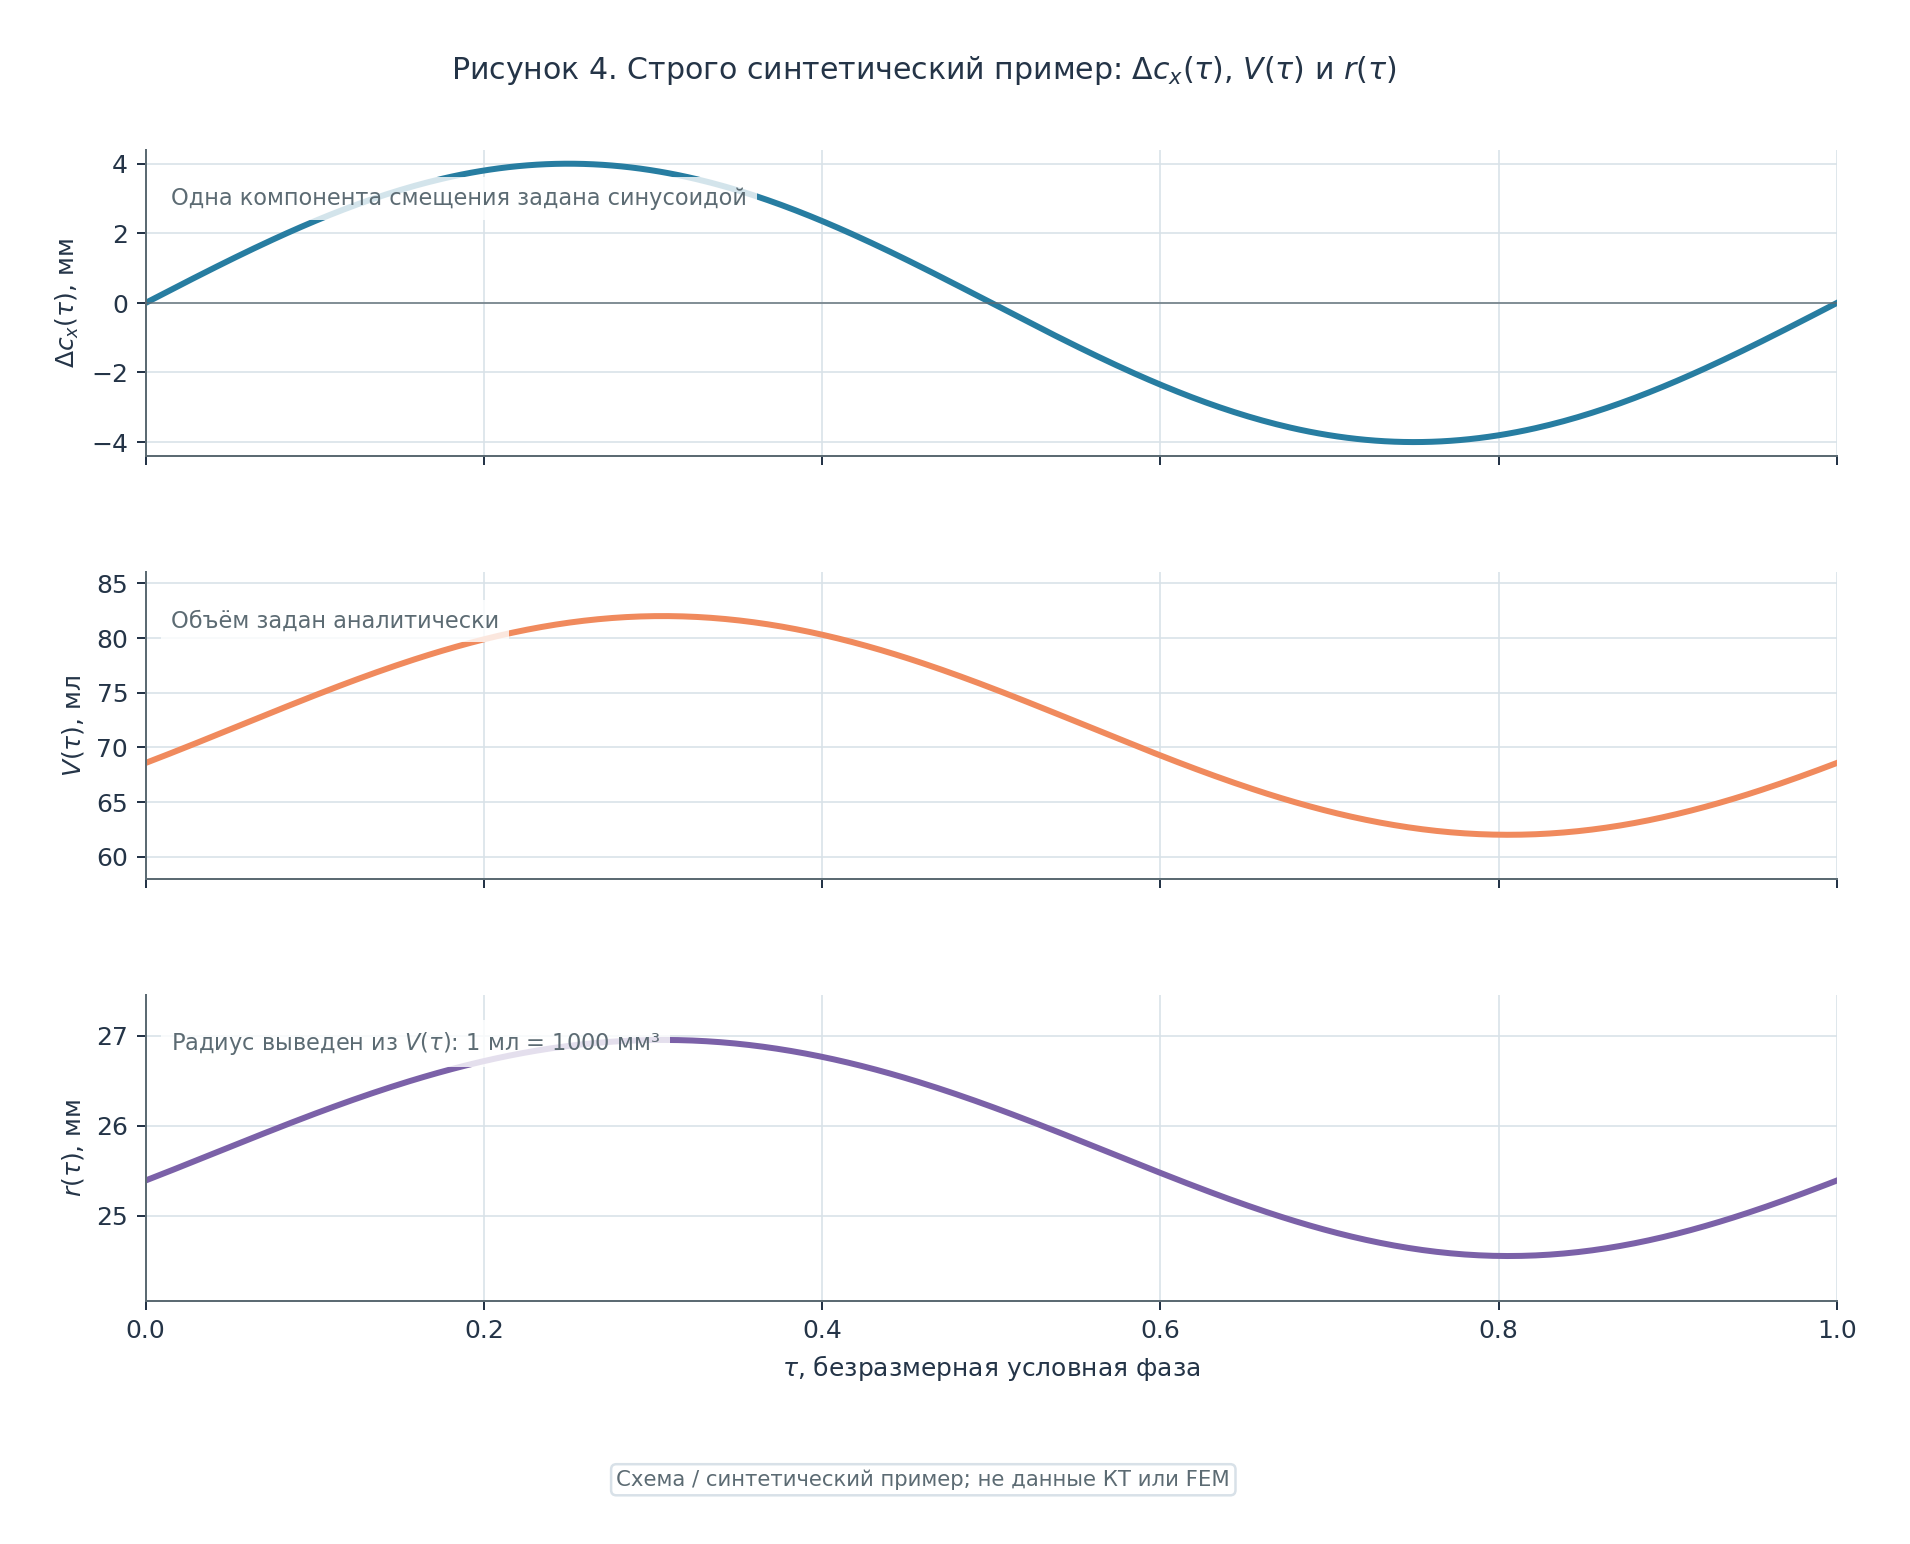

*Рисунок 4. Схема переноса временных изменений в параметры сферы. На искусственно заданной последовательности показаны объём, соответствующий радиус и перемещение центра. Нелинейная связь $r\propto V^{1/3}$ означает, что одинаковые относительные изменения объёма и радиуса неэквивалентны. Пример не задаёт физиологическую амплитуду или длительность цикла.*

## 6. Регистрация, форма и временная устойчивость

В методе Д4 положение исходной маски сопоставляется с каждой последующей посредством явно выбранной регистрации. Для жёсткого движения
$$
\mathbf x_t=\mathcal R_t(\mathbf x-\mathbf c_0)+\mathbf c_0+\mathbf d_t,
$$
где $\mathcal R_t$ — матрица поворота, $\mathbf d_t$ — перенос относительно опорного центра $\mathbf c_0$. У однородной сферы поворот вокруг собственного центра не меняет геометрию. Следовательно, замещение сферой исключает электрический эффект изменения ориентации несферической области.

Перемещение центра объёма и перенос, полученный регистрацией, не обязаны совпадать: изменение формы тоже меняет центр объёма. Если вычислить центр маски после жёсткой регистрации и перенести его обратно тем же преобразованием, получится исходный покадровый центр. Такая операция сама по себе не создаёт нового метода по сравнению с Д1. Отдельный вариант Д4 возникает, когда сфера следует только жёсткому переносу опорной формы, а остаточное изменение центра анализируется отдельно. Сопоставление этих траекторий позволяет оценить зависимость понятия «движение сердца» от выбранного определения.

Метод Д5 может минимизировать сумму ошибок подгонки поверхностей и штрафа за изменение скорости или ускорения параметров. Сглаживание уменьшает вариабельность траектории, но может подавлять действительное движение. Поэтому сохраняются исходные и сглаженные результаты, а степень сглаживания выбирается по отдельному правилу. По одной сглаженной кривой нельзя подтвердить точность сегментации. Периодическое замыкание траектории допустимо только при обоснованной принадлежности кадров одному сопоставимому циклу.

Контрольный эллипсоид позволяет исследовать потерю формы. Пусть
$$
C_H=\frac{1}{V_H}\int_H
(\mathbf x-\mathbf c_H)(\mathbf x-\mathbf c_H)^T\,dV.
$$
Его собственные направления характеризуют ориентацию распределения объёма. Эллипсоид с полуосями $a_i=\sqrt{5\lambda_i}$, где $\lambda_i$ — собственные значения $C_H$, сохраняет этот нормированный второй момент. Его объём не обязан совпадать с исходным. Если полуоси дополнительно масштабируются для сохранения объёма, это становится другим критерием.

Для почти равных собственных значений направление отдельной оси определяется неустойчиво. Резкие повороты таких осей нельзя автоматически интерпретировать как физическое вращение сердца.

Дальнейшим вариантом являются несколько сфер для разных камер. Он расширяет число параметров и требует отдельного контракта областей, их непересечения и электрических свойств. Динамику полости желудочка нельзя без явного указания использовать вместо динамики всего сердечного компартмента.

## 7. Вычислительное разделение перемещения, изменения объёма и остаточного изменения формы

Для каждой маски $H_t$ из одной сопоставимой серии предлагается построить четыре контрольные геометрии на основе опорной маски $H_0$.

1. Исходная опорная геометрия.
2. Только перенос на $\mathbf c_t-\mathbf c_0$.
3. Только равномерное масштабирование относительно $\mathbf c_0$ с коэффициентом $(V_t/V_0)^{1/3}$.
4. Совместное масштабирование и перенос.

Пятая геометрия — фактическая сегментированная область $H_t$, содержащая все наблюдаемые различия относительно $H_0$, включая перенос, изменение объёма и формы. Аналогичные контрольные модели строятся для сферы.

Пусть $F(G)$ обозначает импеданс при геометрии $G$ и фиксированных остальных условиях. Обозначим $T$ перенос, а $D$ масштабирование относительно опорного центра $\mathbf c_0$. Композиция $TD=T\circ D$ означает сначала масштабирование, затем перенос. Величина
$$
I_{TD}=F(TD H_0)-F(T H_0)-F(D H_0)+F(H_0)
$$
характеризует нелинейное взаимодействие этих двух преобразований в принятой прямой модели. Это точное определение разности четырёх расчётов. Оно не предполагает заранее, что два отклика складываются линейно.

Остаток
$$
R_{\mathrm{shape}}=F(H_t)-F(TD H_0)
$$
показывает, что не воспроизводится совместным переносом и равномерным масштабированием опорной формы. Он может включать изменение ориентации, неоднородную деформацию и ошибки масок. Его нельзя объявлять чистым физиологическим вкладом формы.

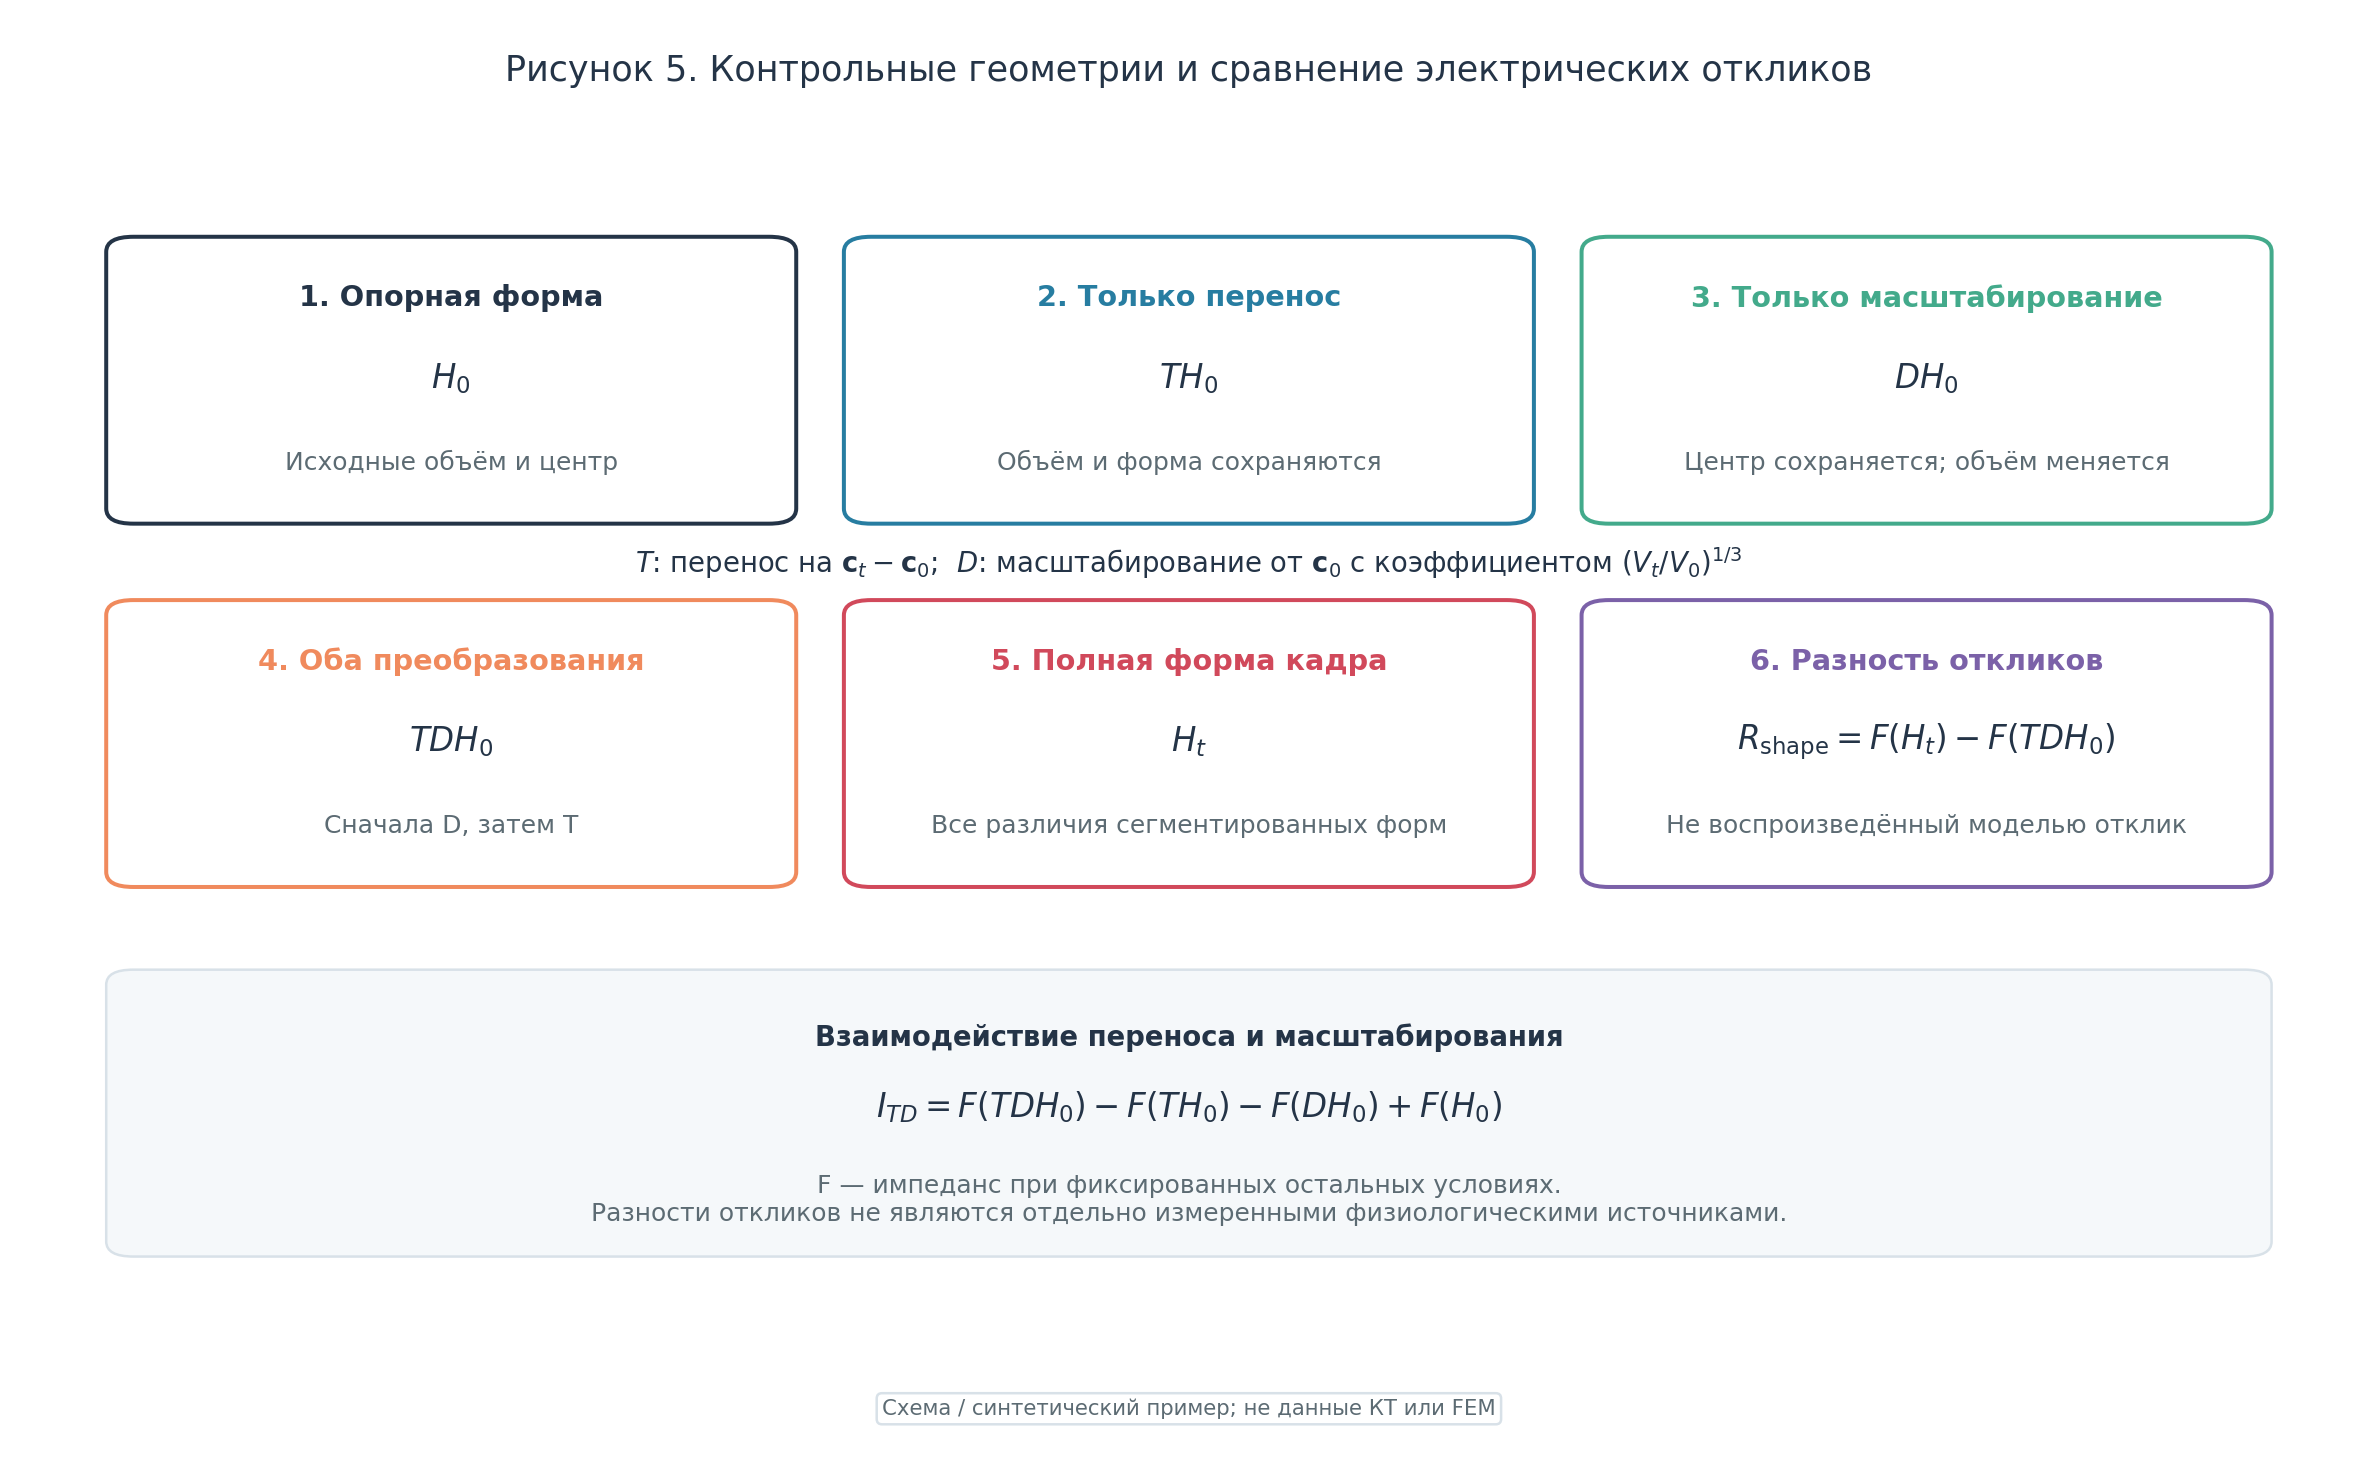

*Рисунок 5. Контрольные геометрические опыты. Разделение выполняется посредством явно заданных преобразований одной опорной формы. Оно помогает установить, какая часть модельного отклика теряется при переходе к сфере. Показанные ветви не являются независимо измеренными источниками сигнала.*

### 7.1. Контроль потери формы при неизменных объёме и центре

Особенно информативна синтетическая проверка, в которой исходная область изменяет форму при неизменных объёме и центре. Например, преобразование
$$
\mathbf x'=\mathbf c_0+A(\mathbf x-\mathbf c_0),\qquad
A=\operatorname{diag}(\alpha,\alpha^{-1},1),\quad \alpha>0
$$
имеет определитель 1 и сохраняет объём. Если $\mathbf c_0$ является центром исходной области, центр также сохраняется. При допустимой геометрии такое преобразование меняет вытянутость, а сфера Г1 остаётся той же. Аналогично можно проверить поворот несферической области вокруг её центра.

Если прямой FEM при этих преобразованиях даёт существенное изменение сигнала, сфера по объёму и центру его не воспроизведёт. Это будет прямой модельный результат о потере информации формы. Если изменение мало в исследованных условиях, получим ограниченное основание для сферического упрощения именно в этих условиях.

Дополнительная модель может сохранять несколько заранее выбранных параметров остаточной формы после регистрации. Набор таких параметров определяется на обучающей части и фиксируется до проверки. Введение остаточной формы увеличивает число неизвестных и должно оправдываться улучшением проверочных электрических откликов.

## 8. Материальная среда при замещении и движении

Геометрическое преобразование не определяет электрическую модель полностью. Необходимо задать материал в области $H\setminus S$, которая перестала принадлежать сердцу, и в области $S\setminus H$, которую заняла сфера. Дополнительно контролируются пересечение с лёгкими, костями и выход за наружную поверхность тела.

Один из проверочных вариантов — заранее определить фоновую модель без сердца, заполнив исходную сердечную область заданной эффективной средой, после чего помещать в неё исходную маску или сферу. Выбор заполнителя является допущением. Его удельное сопротивление и влияние на выводы следует исследовать.

Если сфера перекрывает лёгкое, приоритет сердечного материала уменьшает область лёгкого. Запрет пересечения ограничивает допустимые координаты и радиусы. Обрезание по границе лёгкого изменяет саму форму включения. Эти решения должны рассматриваться раздельно, поскольку они задают разные прямые задачи.

Для каждой модели сохраняются объёмы областей несовпадения, изменения объёмов соседних тканей и выбранное правило назначения материалов. Равенство импедансов, полученное за счёт скрытого изменения лёгких или мягких тканей, не подтверждает эквивалентность сердечной сферы.

Вариант с неподвижными окружающими тканями является вычислительным контролем. Модель их совместной деформации требует дополнительных геометрических входов и собственных условий сохранения объёма или материала.

## 9. Метрики электрической эквивалентности

Для одинаковой сборки и одинакового состояния $\rho$ определяются
$$
\Delta Z^H_t=Z(H_t)-Z(H_{t_0}),\qquad
\Delta Z^S_t=Z(S_t)-Z(S_{t_0}).
$$

**Ошибка исходного импеданса** $e_0=Z(S_{t_0})-Z(H_{t_0})$ показывает соответствие базового состояния и измеряется в Ом. **Ошибка динамического отклика**
$$
e_t=\Delta Z^S_t-\Delta Z^H_t
$$
показывает, насколько замещение сохраняет изменение сигнала. Эти два результата необходимо представлять раздельно: вычитание базы может скрыть большой постоянный сдвиг, а совпадение базы — ошибку динамики.

В отчёт сравнения должны входить:

- абсолютные ошибки $Z$ и $\Delta Z$ в Ом;
- ошибки амплитуды, знака и временного положения особенностей кривой;
- среднеквадратичная и максимальная ошибки по проверенным кадрам;
- ошибки производных по трём координатам центра и радиусу;
- сохранение предпочтительных сборок и существенных попарных различий.

Нормированная ошибка требует заранее заданного ненулевого масштаба. При почти нулевом референсном отклике относительная ошибка неустойчива; следует показывать абсолютные ошибки и сам масштаб. Корреляция кривых не заменяет проверки амплитуды. Произвольное растяжение времени или сдвиг кривой для улучшения совпадения скрывает часть ошибки и не допускается в основном сравнении без отдельного обоснования.

FEM на исходных масках является референсом для оценки геометрического упрощения. Он остаётся результатом математической модели и не становится независимым физическим измерением.

## 10. Чувствительность к координатам и размеру

Для сферы определяются частные производные при фиксированных остальных параметрах:
$$
J_g=\left[
\frac{\partial Z}{\partial c_x},
\frac{\partial Z}{\partial c_y},
\frac{\partial Z}{\partial c_z},
\frac{\partial Z}{\partial r}
\right].
$$
Если координаты и радиус выражены в миллиметрах, элементы $J_g$ имеют единицу Ом/мм. Перемещения задаются в анатомической системе координат. Процент от абсолютной координаты не используется, поскольку зависит от начала отсчёта.

Радиус и объём представляют связанные параметризации:
$$
V_{\mathrm{мл}}=\frac{4\pi r_{\mathrm{мм}}^3}{3000},\qquad
\frac{\partial Z}{\partial V_{\mathrm{мл}}}
=\frac{1000}{4\pi r_{\mathrm{мм}}^2}
\frac{\partial Z}{\partial r_{\mathrm{мм}}}.
$$
Поэтому для размера следует сохранять обе оценки: Ом/мм и Ом/мл. Равные процентные изменения радиуса и объёма не являются равными воздействиями.

Референсную производную исходной маски по перемещению можно определить жёстким переносом. Производная по объёму требует выбранного семейства деформаций, например равномерного масштабирования. Другая деформация с тем же $\Delta V$ может дать другой отклик.

Динамическая траектория 4D-КТ и частные производные отвечают на разные вопросы. Вдоль траектории одновременно могут меняться несколько геометрических параметров и удельные сопротивления. Якобиан описывает малые изменения в заданной точке; конечные движения проверяются прямыми расчётами.

Для восстановления нескольких неизвестных нужна их различимость по набору измерений. Большой отклик одной сборки не гарантирует, что сдвиг по одной оси можно отличить от изменения радиуса или $\rho_H$. После нормировки на согласованные масштабы исследуются ранг и обусловленность совместного якобиана. Эти проверки дополняют оценку целевой чувствительности.

## 11. Проверка численной точности геометрических производных

Изменение удельного сопротивления фиксированной области и изменение её границы являются разными вычислительными задачами. При присвоении целому вокселю или тетраэдру одной тканевой метки малое перемещение может не изменить ни одной метки, а следующее — изменить сразу несколько. Получается ступенчатый отклик, способный исказить производную.

Для каждого выбранного способа представления движущейся границы требуется:

1. проверить физический объём, центр и положение поверхности в каждом состоянии;
2. сравнить центральные разности при нескольких уменьшающихся шагах перемещения или изменения радиуса;
3. отдельно оценить влияние размера объёмных элементов и аппроксимации границы;
4. сопоставить знаки и величины производных с конечными изменениями прямого решения;
5. проверить, сохраняются ли различия между сборками при уточнении расчёта.

Потенциальные способы включают перестроение согласованной сетки, деформацию подходящей сетки или методы учёта пересечения границы с элементами. Их выбор не определяется одним лишь наличием КТ с вокселем 1 мм. Усреднение материала в пересечённом элементе тоже является численной аппроксимацией и требует проверки.

Уже выполненные проверки производных по $\rho$ не объявляются проверками геометрических производных. Проводимая серия пространственных сравнений статических моделей сборок [40.09](40.09_Подготовка_чувствительности_сборок_TEPC.ipynb) даёт необходимый контекст точности, но не заменяет этот этап.

## 12. Независимость подгонки и проверки

Геометрические методы, не использующие импеданс, оцениваются на всех заранее выбранных сборках. Электрически подбираемые методы требуют разделения данных на подгонку и проверку.

Возможные независимые направления проверки: другие сборки, другие состояния $\rho$, другие временные блоки или циклы, другая анатомия. Соседние кадры одной реконструированной серии могут быть связаны; случайное перемешивание кадров не гарантирует независимость.

Использование маски проверяемого кадра для геометрического определения сферы допустимо, если индивидуальная маска является заявленным входом метода. Использование его электрического отклика для настройки сферы с последующей оценкой на том же отклике является подгонкой и не считается независимой проверкой.

Для метода Д6 отдельно проверяются исходный импеданс и динамические изменения. Подгонка только по $\Delta Z$ не определяет автоматически верную исходную геометрию. Все обучаемые ограничения, веса, временное сглаживание и критерии исключения кадров фиксируются до раскрытия проверочных откликов.

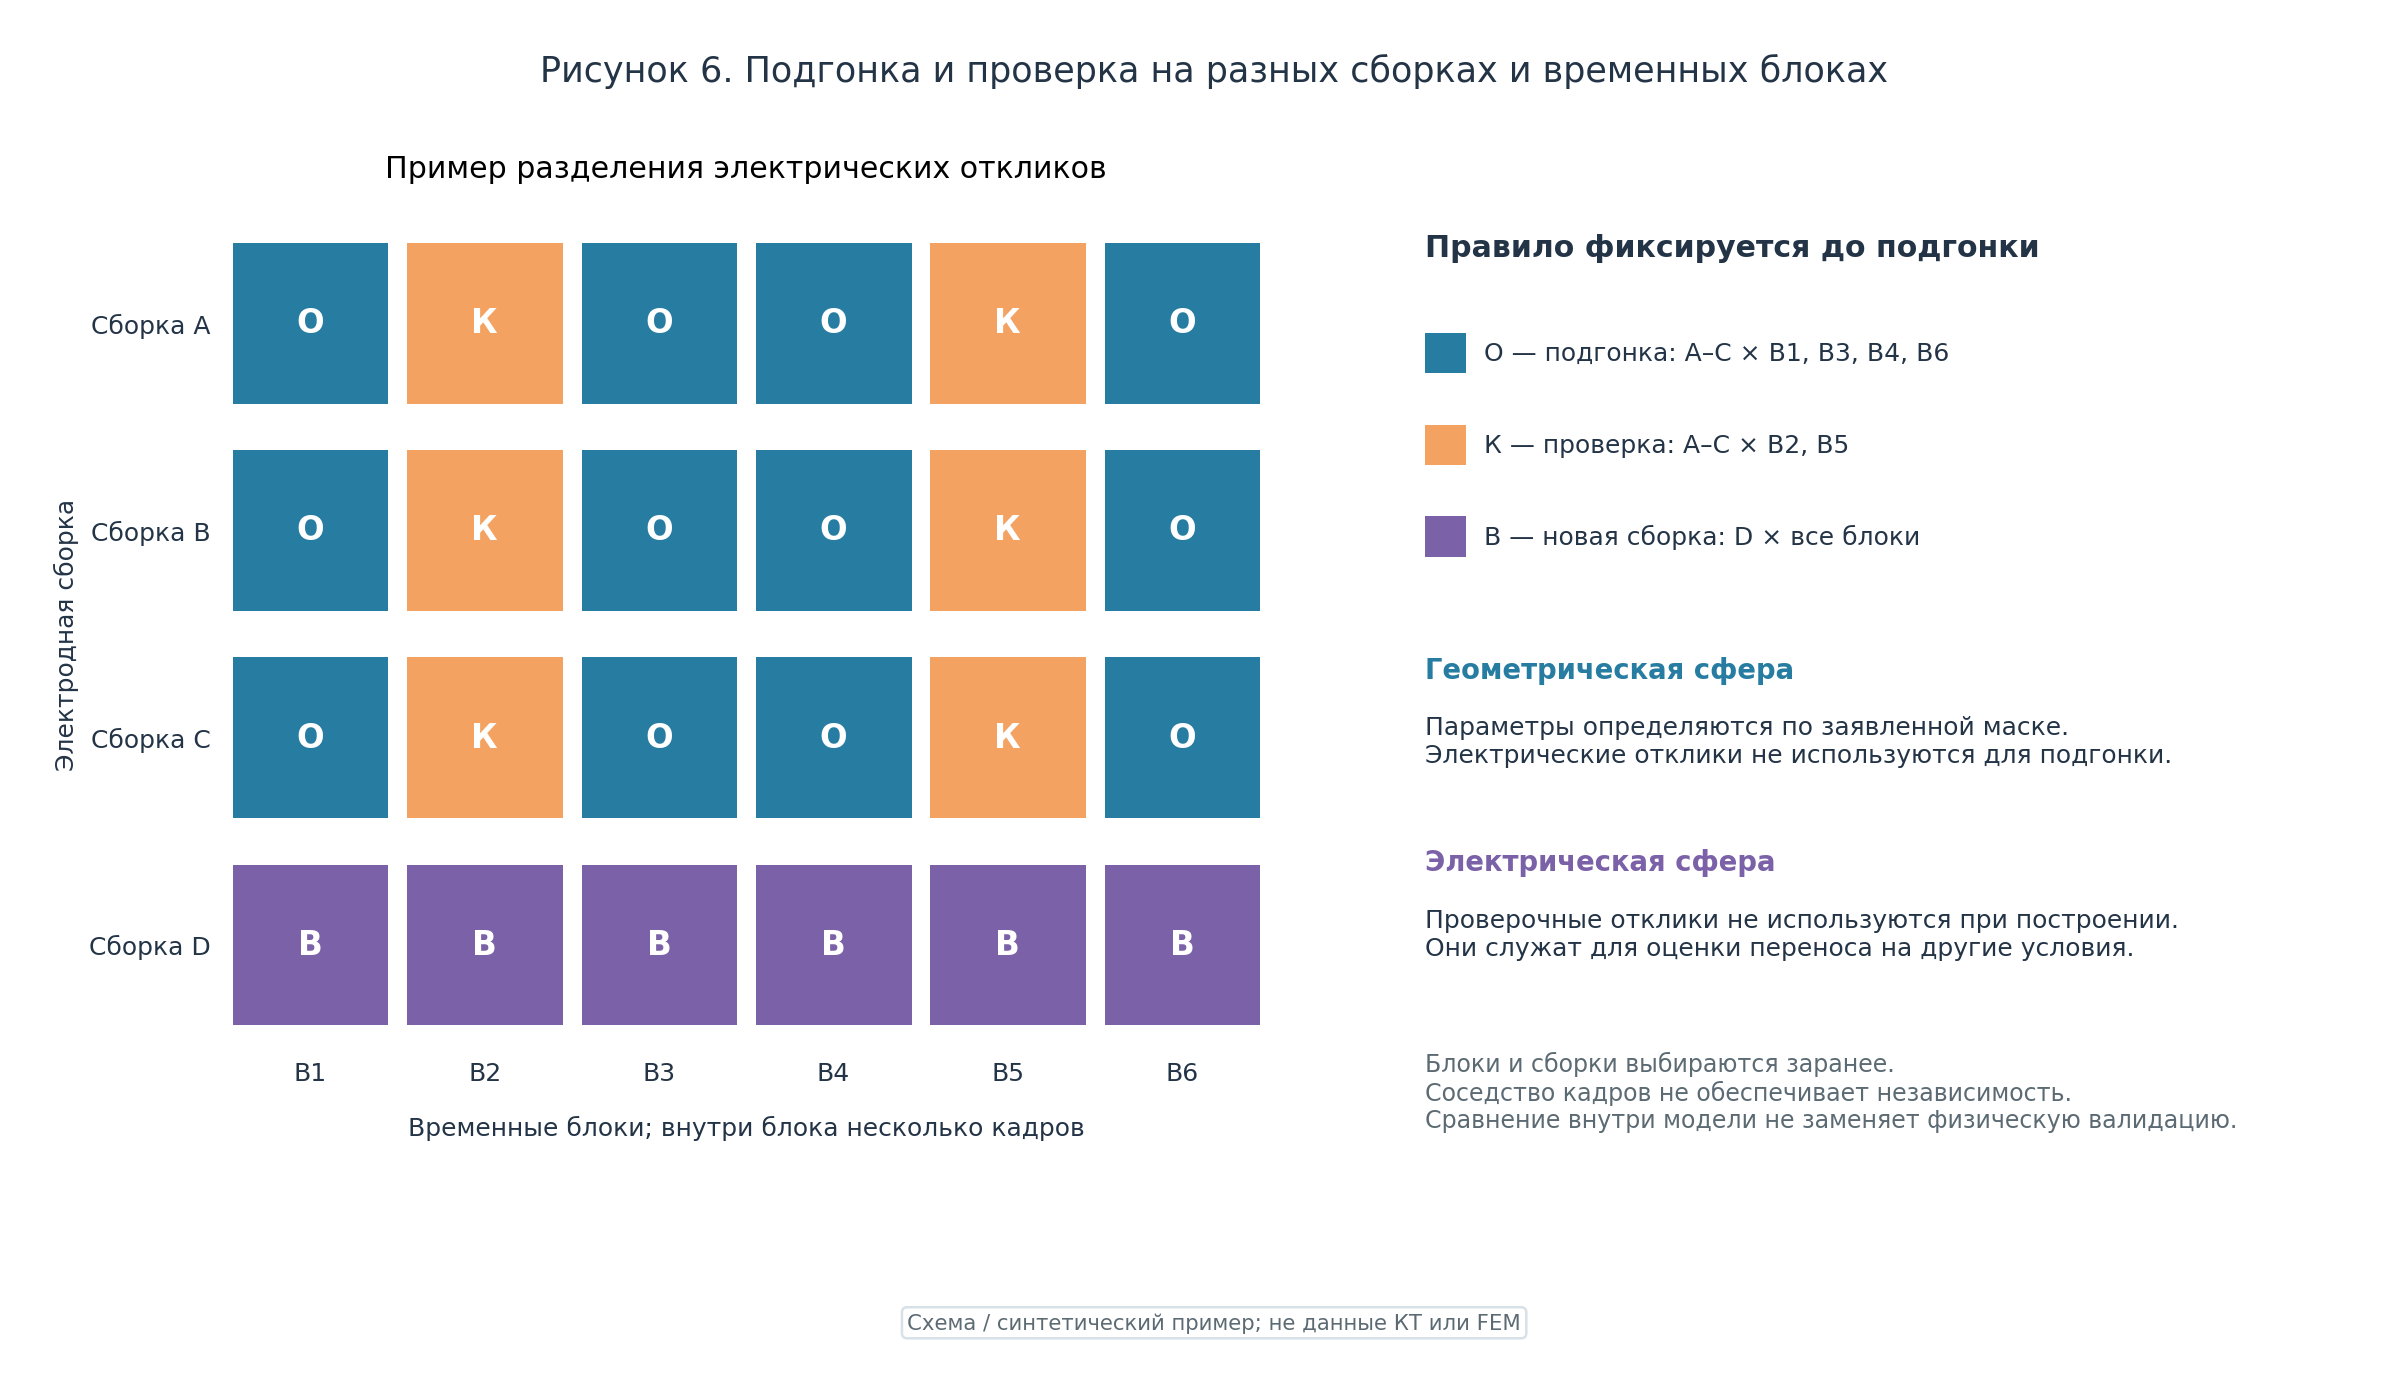

*Рисунок 6. Разделение построения, подгонки и проверки. Геометрическая сфера определяется по заявленным анатомическим входам. Электрическая сфера использует отдельный набор расчётных откликов для подгонки и проверяется на отложенных условиях. Успех этого сравнения характеризует качество упрощения внутри модели; физиологические требования применяются к обоим вариантам с начала их построения, а физическая валидация сохраняется как самостоятельный этап.*

## 13. Последовательность исследования и правила выбора

Сначала определяются целевые физиологические величины и допустимые ошибки, затем совместно рассматриваются несколько представлений формы и законов движения. Г1, Д1, Д2 и Д3 служат контрольными случаями для разложения эффектов. Эллипсоид, модель камер и деформация исходной формы входят в сравнение как самостоятельные кандидаты; их рассмотрение не ставится в зависимость от предварительного неуспеха сферы. Подробная постановка и литературные основания приведены в разделе 17.

| Этап | Требуемый результат | Основание перехода |
|---|---|---|
| Целевые величины и область | Определения сохраняемых функций, тканевых масок и требуемых входов | Физиологический смысл задан до подгонки |
| Геометрические кандидаты | Объёмы, положения, размеры, ориентации и несовпадения с масками | Проверены единицы, координаты, допустимость материалов и пересечений |
| Динамические кандидаты | Пофазные параметры и ограниченные временные законы | Объявлены обучение, проверка и временные соответствия |
| Прямая проверка | Физиологические показатели, импедансы, производные и ошибки | Достигнута требуемая численная точность для каждой пары формы и закона |
| Сравнение сборок | Различия по выбранной чувствительности | Оценена устойчивость разностей и предпочтений |
| Выбор приближения | Достаточная модель с минимальной необходимой индивидуализацией | Совместно выполнены обязательные критерии на проверочных условиях |
| Обратная задача и независимая валидация | Неопределённость целевых оценок и область переноса | Разделены информация измерений, влияние ограничений и независимый референс |

До фиксации численных пределов ошибок нельзя принимать метод только по форме графиков. Допуски учитывают назначение оценки, вычислительную погрешность и неопределённость входов. Совместная постановка не позволяет компенсировать нарушение физиологического требования улучшением электрической подгонки. Увеличение сложности должно давать проверяемое улучшение за пределами обучающих условий.

## 14. Практическое толкование

Нужно выбрать не только форму, но и способ её изменения, при котором параметры имеют объявленный физиологический смысл и достаточно точно воспроизводят электрический сигнал. Простые тела и исходная индивидуальная форма с небольшим числом деформаций являются разными способами сокращения задачи.

4D-КТ позволяет сравнить эти способы на одной последовательности анатомических состояний. Пофазная подгонка показывает ошибку представления формы, а введение общего временного закона — дополнительную ошибку ограничения движения. Контроли изменения только размера, положения или формы помогают объяснить происхождение расхождений.

Ни один кандидат пока не выбран как оптимальный. Рабочая гипотеза состоит в переносимости структуры модели и части ограничений при индивидуальной настройке размеров, положения и небольшого числа коэффициентов. Общая для всех людей траектория без индивидуальных входов не предполагается установленной.

## 15. Что доступно в текущей ветке 4D-КТ

**Факт инвентаризации проекта на 14.09.2026:** в ветке [21.00 — карта 4D-сегментации и R–R](cardiac_4d_segmentation/21.00_Карта_4D_сердца_и_RR.md) описаны три обезличенные серии, содержащие 12, 12 и 15 фаз, всего 39. Для всех 39 фаз уже получены маски TotalSegmentator 2.18.0, используемые в 21.03. Эти результаты сохраняются для дальнейшего анализа; повторная сегментация трёх серий не требуется. Ниже перечислены существующие производные этой ветки. Их повторное вычисление в данном ноутбуке не выполнялось.

| Вход | Определение и доступность | Значение для замещения |
|---|---|---|
| Фазовые КТ и преобразование координат | NIfTI во внешнем хранилище; параметры сетки и преобразования в манифесте conversion_manifest.json | Физические координаты, объём вокселя и соответствие фаз |
| Целое сердце, whole_heart | Отдельная автоматическая маска задачи total/heart | Основной кандидат для продолжения нынешней модели целого сердечного компартмента |
| Кровь камер, blood_pool | Объединение четырёх камер; аорта и лёгочная артерия исключены | Отдельный кандидат, анатомически более близкий исторической модели крови сердца |
| LA, LV, RA, RV | Четыре непересекающиеся автоматические маски камер | Анализ объёмов и геометрии камер; построение многосферных вариантов |
| myocardium | Автоматическая маска миокарда после удаления пересечения с кровью | Не является надёжно выделенным полным миокардом всех камер |
| heart_minus_blood | Целое сердце за вычетом крови камер | Диагностический геометрический остаток; не подменяет миокард |

Для каждой фазы имеются три основных продукта NIfTI и соответствующие STL. Для количественной геометрии исходным объектом принимается NIfTI-маска с проверенным преобразованием координат. STL сам по себе не хранит единицы; сглаживание поверхности может изменить объём. Вершины интерактивного HTML также не являются количественным источником.

Таблица heart_rr_analysis/chamber_volumes_by_rr.csv содержит объёмы целого сердца, камер и диагностических областей. Локальный кэш heart_rr_analysis/function_analysis/chamber_geometry.csv содержит центры и геометрические показатели **четырёх камер**. Готовых центров целого сердца и объединённой крови в проверенных количественных таблицах нет. Их расчёт по маскам станет новым производным результатом следующего этапа. Кэш function_analysis исключён из Git; переносимость обеспечивается через исходные маски, манифест и воспроизводимый расчёт, а не наличием таблицы на одном компьютере.

Для физических координат используется переход DICOM LPS → NIfTI RAS+. В существующих NIfTI поле единиц может иметь значение unknown; миллиметровый масштаб следует подтверждать по conversion_manifest.json и исходной КТ-сетке. Для маски с $N$ полными вокселями и пространственной частью affine-матрицы $A$
$$
V_{\mathrm{мл}}=N|\det A|/1000
$$
при условии, что $A$ задана в миллиметрах. Центр вычисляется по физическим координатам центров вокселей. Усреднять номера вокселей и затем объявлять их миллиметрами нельзя.

Временные поля восстановлены из DICOM, включая GE RpeakTimeStamps. Они не являются цифровой ЭКГ. Для двух серий предварительно разрешено сопоставление циклов; в третьей объединение отклонено, и короткий и длинный интервалы сохраняются раздельно. Временная ширина реконструкции не равна автоматически промежутку между кадрами. Эти решения принадлежат ветке 21 и не должны незаметно пересматриваться при построении сферы.

**Ограничение исходной анатомии:** маски имеют статус automatic_segmentation_pending_manual_review. Независимые ручные референсные маски в проверенном хранилище не найдены. Согласие двух автоматических моделей не устанавливает их точность относительно анатомии. Изменение центра между кадрами пока объединяет движение, деформацию, реконструкционные различия и ошибки сегментации. Наблюдаемые экстремумы объёма не объявляются принятыми конечной диастолой и систолой.

Из этих данных предлагаются две самостоятельные ветви:

1. **Целое сердце → сфера целого сердечного компартмента.** Сохраняется предмет нынешней статической постановки; эффективное $\rho_H$ остаётся явно заданным допущением.
2. **Кровь четырёх камер → сфера крови.** Меняется предмет замещения. Для крови и оставшихся тканей необходим новый согласованный материальный состав модели. Нынешнее эффективное $\rho_H$ смеси крови и миокарда не переносится на чистую кровь автоматически.

По принятому в ветке 21 решению автора работу продолжают на исходных автоматических масках без обязательного создания нового ручного референса. Обе ветви можно исследовать как условные вычислительные опыты на этих масках. Контроль анатомической точности сегментации необходим для достоверной анатомической и физиологической интерпретации. Его отсутствие ограничивает эту интерпретацию, но не блокирует условный вычислительный эксперимент. Перенос траектории из одной серии в грудную клетку другого испытуемого является отдельным допущением о переносимости; он не создаёт индивидуальную 4D-модель Nix.

Минимальная входная запись будущего расчёта должна содержать идентификатор серии и фазы, вариант маски, контрольную сумму файла, affine и основание единиц, источник времени, статус ручного контроля и правило сопоставления с грудной клеткой. Для каждого кандидата сохраняются $V_t,\mathbf c_t,r_t$, опорная фаза и метод построения. Отсутствие подтверждённой геометрии блокирует количественный расчёт. Отсутствие временной привязки блокирует временные производные и физиологическую трактовку; отдельное статическое сравнение доступных масок может быть проведено с явным ограничением.

### 15.1. Исторические контрастные КТ и будущая проверка изменения объёма

По технической инвентаризации проекта от 14.09.2026 каталог OLD содержит девять каталогов исторических исследований и 413 объектов Enhanced CT. Выделены 17 полных групп по 20 фаз: от 0 до 95% с шагом 5%; ещё одна группа содержит 18 фаз от 10 до 95%. Отдельно имеются тонкосрезовые серии. Во всех 413 объектах в общих функциональных группах DICOM признак ContrastBolusAgentAdministered имеет значение YES. Это подтверждает запись о введении контрастного вещества, но не устанавливает качество контрастирования камер в каждой фазе.

В полных фазовых группах заявленная толщина среза SliceThickness равна 5 мм, а фактический шаг плоскостей по ImagePositionPatient — 2,5 мм. В отдельных тонкосрезовых сериях эти величины составляют 0,5 и 0,25 мм соответственно. Толщину среза нельзя подставлять вместо пространственного шага при построении сетки и расчёте объёма. Тонкосрезовые серии не объединяются с фазовыми без отдельного согласования геометрии и времени.

В нормализованной части архива _OLD_SUBJECTS обнаружены 324 объекта Enhanced CT в семи сессиях четырёх людей; у пятого человека имеются только сопроводительные материалы. Протокол нормализации связывает эти файлы с OLD и его архивными копиями, поэтому их нельзя учитывать как дополнительную независимую выборку. В этой части архива нет SPJ, STL, NIfTI и объектов DICOM SEG/RTSTRUCT. Автор подтвердил отсутствие готовых референсных масок для планируемой проверки. Их создание отложено; подготовка данных и исследование на автоматических масках продолжаются.

Приоритет будущей парной проверки — ошибка изменения объёма между двумя состояниями, отдельно для каждой заявленной области сердца. Пусть $V_{\mathrm{TS}}(t)$ — объём автоматической маски TotalSegmentator, а $V_{\mathrm{ref}}(t)$ — объём будущей независимой референсной маски той же области в той же фазе; оба объёма выражены в мл. Тогда
$$
e(t)=V_{\mathrm{TS}}(t)-V_{\mathrm{ref}}(t),\qquad
\delta(\Delta V)=\bigl[V_{\mathrm{TS}}(t_2)-V_{\mathrm{TS}}(t_1)\bigr]-\bigl[V_{\mathrm{ref}}(t_2)-V_{\mathrm{ref}}(t_1)\bigr]=e(t_2)-e(t_1),
$$
где $e(t)$ — ошибка объёма относительно референса в состоянии $t$; $t_1,t_2$ — два сопоставляемых состояния, не обязательно конечная диастола и систола; $\delta(\Delta V)$ — ошибка изменения объёма, мл. Постоянная аддитивная составляющая ошибки сокращается при вычитании, а различие ошибок между фазами сохраняется. Поэтому ошибки абсолютного объёма и его изменения оцениваются раздельно.

Сейчас можно рассчитывать автоматические $V$ и $\Delta V$, проверять геометрию, согласованность фаз и качество масок, а также готовить структуру парного сравнения. Количественная ошибка относительно независимого референса пока не определяется; отсутствие оценки не означает нулевую ошибку. Будущие ручные маски должны создаваться по исходным изображениям и заранее принятому правилу разметки независимо от результатов TotalSegmentator. Подгонять референс под автоматическую маску или её объём недопустимо.

## 16. Сопоставление с диссертацией Тихомирова и отчётами РФФИ

### 16.1. Порядок и границы разбора

Набор методов разделов 1–14 зафиксирован до чтения содержания исторических источников. Его неизменяемая копия и контрольная сумма сохранены в [архиве независимой постановки](../MATLAB_TRKG4_real_subjects/docs/archive/heart_sphere_independent_pool_20260914.md) и [манифесте](../MATLAB_TRKG4_real_subjects/docs/HEART_SPHERE_METHOD_POOL_20260914.json). После этого сформирован [фиксированный корпус источников](../MATLAB_TRKG4_real_subjects/docs/HEART_SPHERE_SOURCE_CORPUS_20260914.json): диссертация, автореферат и две локальные версии отчётов.

Это адресное сопоставление методик по указанным автором материалам, а не систематический обзор всей литературы. Основные утверждения проверены по диссертации и отчётам; автореферат не используется как замена более подробному первоисточнику. Формулы, таблицы и ключевые страницы дополнительно просмотрены в PDF. Далее слова «авторы получили» относятся к результатам соответствующего источника, а не к повторному расчёту в настоящем проекте.

Ссылки открывают страницы локальных PDF через Zotero. У отчёта 2021 года печатный номер страницы на два больше номера страницы PDF; оба номера указаны там, где возможна неоднозначность.

### 16.2. Диссертация: контурная сфера и обратная задача

В диссертации Тихомирова исследуется сфера, представляющая **кровь в сердце**, в том числе совместно кровь желудочков и предсердий. В разделе 4.2 сравниваются два способа начального геометрического определения: приближение МРТ-контура методом наименьших квадратов и построение по центру с сохранением площади сечения. Описанное сохранение площади нельзя отождествлять с сохранением полного 3D-объёма в методе Г1. [1, с. 75–78](zotero://open-pdf/library/items/NUZKBZGS?page=75)

Для понимания различия введём математическую запись второго подхода: круг площади $A$ имеет радиус $r_A=\sqrt{A/\pi}$. Это поясняющая формула настоящего разбора. Получаемый из такого радиуса объём шара не обязан совпадать с объёмом исходной трёхмерной области. Контурный способ также требует отдельного задания глубины центра относительно поверхности тела.

В дальнейшем в источнике одновременно подбираются изменения радиуса и трёх координат общей сферы по изменениям импеданса пяти каналов. Такой подход соответствует обратной электрической задаче и близок по цели к методу Д6. Он не означает, что восстановленная электрическая траектория автоматически является независимо измеренной траекторией анатомического центра. [1, с. 79–83](zotero://open-pdf/library/items/NUZKBZGS?page=79)

Начало координат и преобразования в системы отдельных каналов определяются электродной схемой источника. Траектории далее восстанавливаются по последовательным интервалам сердечного цикла. Эти координаты нельзя непосредственно подставить в нашу NIfTI RAS+ или FEM-модель без установления осей, единиц, начала отсчёта и регистрации. [1, с. 81–85](zotero://open-pdf/library/items/NUZKBZGS?page=81)

Автор также рассматривает влияние противоположно направленных изменений объёмов предсердий и желудочков и вводит дополнительную модель для перехода к ударному объёму. Следовательно, даже в исторической постановке изменение объёма общей сферы не используется как безусловно равное ударному объёму. Перенос соответствующей поправки в нашу модель потребовал бы проверки её анатомического предмета, приборной постановки и точности. [1, с. 79–80](zotero://open-pdf/library/items/NUZKBZGS?page=79)

**Вывод сопоставления:** диссертация даёт предшествующий пример общей для нескольких каналов электрической сферы, контурной инициализации и восстановления её движения. Она не подтверждает автоматически пригодность равновеликой сферы целого сердца для текущих TEPC-сборок.

### 16.3. РФФИ 2020: поверхность, заполнение внутренних структур и эллипсоид

В отчёте 2020 года сопоставляются сферические и эллипсоидальные приближения 3D-геометрии. Один из критериев минимизирует сумму квадратов расстояний точек до поверхности. Это близко к группе Г3, однако равные веса точек и площадочная квадратура поверхности являются разными дискретными критериями. Их совпадение нельзя предполагать при неравномерном распределении вершин. [2, § 1.5.1, с. 35–36](zotero://open-pdf/library/items/SG58QNPU?page=35)

Источник отдельно показывает роль подготовки поверхности: внутренние структуры и полости меняют подгонку. Описано заполнение по двумерным сечениям с последующим восстановлением 3D-области. После такой обработки повторно сравниваются объёмы приближений. [2, с. 38–40](zotero://open-pdf/library/items/SG58QNPU?page=38)

Для нашего проекта это самостоятельный методический фактор. «Исходная кровь камер» и «заполненная внешняя оболочка» являются разными геометрическими объектами. Заполнение нельзя скрывать внутри технической очистки сетки: оно меняет объём, центр и область назначения материала. Уменьшение ошибки подгонки заполненной оболочки не доказывает, что её объём равен физиологическому объёму крови.

### 16.4. РФФИ 2021: динамическая геометрия уже проверялась по электрическому отклику

В отчёте 2021 года поставлен именно тот вопрос, который определяет следующий этап проекта: недостаточно сравнить только объёмы; необходимо проверить положение, форму и изменение электрического отклика. В описанной серии для каждого из четырёх добровольцев использовано по 20 реконструированных кадров сердечного цикла. Эти характеристики относятся к корпусу отчёта. Они не совпадают с автоматически установленными характеристиками нынешних трёх серий из раздела 15 и не переносятся на них без проверки происхождения. [3, § 11.1–11.2, печ. с. 141–143; PDF 139–141](zotero://open-pdf/library/items/3NAQJNXQ?page=139)

В таблице 34 отчёта средние ошибки объёма сферы по четырём исходным сериям составляют 18, 14, 14 и 18 %, а эллипсоида — 3,8, 7,0, 3,7 и 3,4 %. Это значения таблицы источника для его способа аппроксимации и подготовки геометрии. **Они не являются оценкой ошибки Г1:** у равновеликой сферы ошибка объёма по определению равна нулю, хотя ошибки формы и электрического отклика могут оставаться существенными. [3, табл. 34, печ. с. 146; PDF 144](zotero://open-pdf/library/items/3NAQJNXQ?page=144)

Далее сравниваются траектории центров исходной области, сферы и эллипсоида. В источнике меняются система координат и начало отсчёта. В версии v2.1 около формулы нормировки координат остаётся редакционное замечание о процентах и миллиметрах. Поэтому эти относительные координатные ошибки не принимаются в качестве готовых критериев нашего проекта. Для нового сравнения предпочтительны абсолютные ошибки в миллиметрах и явно определённые перемещения относительно общей опорной фазы. [3, печ. с. 147–152; PDF 145–150](zotero://open-pdf/library/items/3NAQJNXQ?page=145)

Электрическая проверка выполнена для исходной 3D-области крови, сферы и эллипсоида в модели однородного полупространства. Электроды располагались вдоль и поперёк длинной оси сердца; расстояние между токовыми электродами изменялось от 80 до 240 мм при отношении расстояния между токовыми электродами к расстоянию между измерительными электродами 2:1. Это существенно более конкретная постановка, чем общее утверждение об эквивалентной сфере. [3, § 11.4, печ. с. 157; PDF 155](zotero://open-pdf/library/items/3NAQJNXQ?page=155)

На рисунках 123–125 приведены временные изменения импеданса для трёх геометрических моделей. Их следует сопоставлять одновременно по масштабу вертикальной оси, амплитуде, форме кривой и монтажу. Внешне похожее направление изменения само по себе не устанавливает количественное совпадение: шкалы панелей различаются. [3, рис. 123–125, печ. с. 158; PDF 156](zotero://open-pdf/library/items/3NAQJNXQ?page=156)

В заключении этого опыта авторы связывают лучшее количественное соответствие сферы с большими расстояниями между токовыми электродами, свыше 180 мм; преимущество эллипсоида обсуждается для расстояний между токовыми электродами менее 140 мм, с особенностями отдельных добровольцев. Эти границы — **вывод источника в его расчётных условиях**. Их нельзя превращать в рекомендации для наших TEPC-положений, анатомической грудной клетки, контактов диаметром 5 мм и иной материальной модели. [3, печ. с. 162; PDF 160](zotero://open-pdf/library/items/3NAQJNXQ?page=160)

**Главный результат исторического разбора:** необходимость сравнивать электрические изменения исходной формы и сферы уже была реализована в РФФИ. Наш следующий этап должен уточнить критерий эквивалентности, воспроизвести соответствующий контроль и проверить перенос на нынешнюю КТ/FEM-постановку. Это продолжение и расширение методики, а не доказательство того, что любая сфера пригодна для любой сборки.

### 16.5. Как исторические варианты дополняют исходный набор

| Исторический вариант | Связь с независимо сформулированными методами | Что нужно сохранить при воспроизведении |
|---|---|---|
| И1. Центр и равная площадь МРТ-контура | Отличается от Г1 с равным 3D-объёмом | Плоскость сечения, контур, центр, способ задания глубины |
| И2. Наименьшие квадраты по контуру | Двумерный родственник Г3 | Выбор и веса точек, область предсердий/желудочков, критерий расстояния |
| И3. Подгонка 3D-поверхности после определённой обработки | Близка Г3; отдельная от Г1 группа | Исходная и заполненная маски, правила обработки, конкретный критерий и алгоритм источника |
| Общая сфера по изменениям пяти импедансов | Близка Д6 | Модель среды, роли каналов, электродные координаты, поправки и ограничения обратной задачи |
| Пофазное сравнение исходной формы, сферы и эллипсоида | Связано с Д1–Д6 и контрольным эллипсоидом | Пофазные входы, критерий каждой аппроксимации и раздельные геометрические/электрические ошибки |

Варианты И1–И3 добавлены **после** чтения источников и обозначены отдельно. Совпадение общей идеи не означает идентичность математического критерия. Название исторического алгоритма также не является достаточной спецификацией: перед воспроизведением следует сверить формулу, реализацию, веса точек и единицы.

### 16.6. Какие операции подтверждаются просмотром исторического кода

Отдельно выполнено чтение исходников ветки Tikhomirov. Wolfram-код при этом не исполнялся. Его содержание рассматривается как свидетельство реализации отдельных операций, а не как доказательство совпадения с каждым опубликованным расчётом. Состояние Python-порта рассмотрено в разделе 16.7.

В [SphereMovingFunction.m](../Tikhomirov/WolframMath-master/Kernel/part1/SphereMovingFunction.m) критерий равен сумме квадратов радиальных отклонений точек двумерного контура:
$$
E(\mathbf c,r)=\sum_i(\|\mathbf p_i-\mathbf c\|-r)^2.
$$
Предусмотрены совместная подгонка центра и радиуса, подгонка одного радиуса при центре площади контура, а также радиус по равной площади. Это подтверждает необходимость раздельного учёта вариантов И1 и И2.

В том же файле присутствует функция радиуса по МРТ-объёму с дополнительными множителями:
$$
r=10\left(\frac{2\cdot3V_{\mathrm{МРТ}}}{0{,}6\cdot4\pi}\right)^{1/3}.
$$
В [Python-порте](../Tikhomirov/cardio-model-py/src/cardio_model/sphere_fit.py) для неё указаны единицы: мл на входе и мм на выходе. Такая формула не является формулой равновеликого шара: внутри кубического корня дополнительно действует множитель $2/0{,}6$. Его физиологическое обоснование не установлено в рамках настоящего аудита. В проверенных ветвях совместной контурной подгонки переданный радиус не используется, поэтому наличие функции ещё не доказывает её участие в конкретном результате.

В [EqualSphereMoveModellingLib.m](../Tikhomirov/WolframMath-master/Kernel/part1/EqualSphereMoveModellingLib.m) сдвиг центра рассчитывается после построения изменённого контура по импортированным смещениям по каналам. Сферы отдельно подгоняются к исходному и изменённому контурам; затем вычитаются их центры. Это расчётный двумерный сдвиг, а не непосредственно измеренная трёхмерная траектория.

В просмотренных модулях не найден законченный расчёт пары временных откликов исходной 3D-формы и сферы с оценкой их расхождения. [Project/RFFI.m](../Tikhomirov/WolframMath-master/Kernel/Project/RFFI.m) содержит геометрическую обработку STL, включая вокселизацию и морфологическое замыкание. Связь этого файла с электрическим сравнением раздела 11.4 отчёта по просмотренным исходникам не установлена. Наличие графиков в отчёте подтверждает описание проведённого опыта, но для его воспроизведения ещё нужно найти точную расчётную реализацию и входы.

**Следствие для подготовки расчётов:** исторические операции следует воспроизводить только после установления их критерия, единиц, назначения и фактического места в расчёте. Рабочий код сферической модели и геометрический подбор окружности сами по себе не образуют проверенную цепочку перехода от 4D-анатомии к электрическому сигналу.


### 16.7. Реализации в папке Tikhomirov и их применимость к следующему этапу

Папка содержит исходную библиотеку Wolfram/Mathematica, Python-порт её расчётного ядра, заготовку обработки STL и отдельный Mathcad-черновик. Готовность этих частей различается. Ниже состояние реализации устанавливается по содержимому исходных файлов; описания запланированных функций в README не считаются выполненной реализацией.

| Часть исторической ветки | Подтверждённая реализация | Применение и границы |
|---|---|---|
| [Подбор окружности в Python](../Tikhomirov/cardio-model-py/src/cardio_model/sphere_fit.py) | Центр площади многоугольника, радиус по равной площади, минимизация отклонений точек контура с подбором центра и радиуса либо одного из них | Позволяет воспроизвести контурные варианты И1 и И2. Обрабатывает двумерный контур; для замещения трёхмерной маски нужен отдельный алгоритм |
| [Прямая электрическая модель в Python](../Tikhomirov/cardio-model-py/src/cardio_model/models.py) | Импеданс объёмного сферического включения в однородном полупространстве; вклад сферы вычисляется рядом Лежандра | Кандидат для отдельной проверки упрощённой постановки. Параметризация глубины требует уточнения, приведённого ниже |
| [Пять радиальных каналов](../Tikhomirov/cardio-model-py/src/cardio_model/radial.py) и [обратные поиски](../Tikhomirov/cardio-model-py/src/cardio_model/finders.py) | Отдельные скалярные поиски изменения радиуса по каналам; смещение центра в соответствующей ветви задаётся извне | В прочитанном Python-коде нет совместного восстановления трёх координат центра и радиуса по совокупности сигналов |
| [Контурный расчёт в Python](../Tikhomirov/cardio-model-py/src/cardio_model/pipeline.py) и [расчёт объёма](../Tikhomirov/cardio-model-py/src/cardio_model/volume.py) | Разность центров двух подогнанных окружностей; объём по круглым сечениям с суммированием усечённых конусов | Смещение центра двумерно. Объём получен из контурной модели и не равен автоматически объёму исходной трёхмерной маски |
| [Движение сферы в Mathematica](../Tikhomirov/WolframMath-master/implem/sphereMove/SphereMoveModelling.nb) | Ноутбук вызывает библиотечный расчёт и сохраняет исходный и изменённый контуры вместе с подогнанными окружностями | Полезен для установления исторической последовательности операций. Сохранённые выходы не подтверждают повторный запуск в текущем окружении |
| [Обработка STL в Mathematica](../Tikhomirov/WolframMath-master/Kernel/Project/RFFI.m) | Вокселизация, морфологическое замыкание, восстановление поверхности и экспорт точек | Может объяснить подготовку геометрии исторического опыта. Изменение границ и объёма при обработке нужно учитывать отдельно |
| [Заготовка обработки STL в Python](../Tikhomirov/cardio-stl-repair/src/cardio_stl_repair/repair.py) | Файл содержит описание предполагаемых этапов; вычислительных функций в нём нет | Не является готовым средством подготовки 4D-геометрии. Два имеющихся теста проверяют импорт модулей, но не обработку поверхности |
| [Python-черновик Mathcad-модели](../Tikhomirov/mathcad/sphere_mathcad_sketch.py) | Расчёт импеданса, перебор удельного сопротивления и изменения радиуса | Представляет дополнительную историческую реализацию для проверки формул. В функции поправки сопротивления сохранено выражение с вычитанием квадратной и кубической степеней геометрических констант; его происхождение и размерностная согласованность требуют отдельного разбора |

**Раздельное изменение размера и положения.** В функции расчёта влияния сферы расстояния до электродов содержат величину $R+h$. Следовательно, фактическая глубина центра в этой параметризации равна $c_\perp=R+h$, где $c_\perp$ — расстояние от плоскости электродов до центра по нормали в локальной системе полупространства. При этом документация функции называет глубиной центра сам параметр $h$; текст и вычисляемое выражение не согласованы. Для интерпретации текущего кода необходимо исходить из используемой в формулах величины $R+h$.

Если менять радиус при постоянном $h$, центр тоже перемещается. Для одной и той же прямой модели правило дифференцирования сложной функции даёт
$$
\left.\frac{\partial Z}{\partial R}\right|_h
=
\left.\frac{\partial Z}{\partial R}\right|_{c_\perp}
+
\left.\frac{\partial Z}{\partial c_\perp}\right|_R.
$$
Здесь удельные сопротивления, электроды и остальные координаты фиксированы; все производные выражаются в Ом/м при длинах в метрах. Левая часть описывает совместное изменение размера и глубины. Для опыта «только размер» центр необходимо удерживать неподвижным: при каждом новом $R$ задавать $h=c_\perp-R$. Для опыта «только глубина» фиксируют $R$. При этом сфера должна оставаться внутри допустимой области полупространства. В новой реализации предпочтительно сразу задавать радиус и три физические координаты центра независимо, с явным преобразованием локальных осей к координатам КТ. Это уточнение параметризации само по себе не подтверждает точность исторической электрической модели.

**Статус проверок.** Повторный разбор Python-порта выполнен чтением исходников и тестов; численные тесты в этом разборе не запускались. Имеющиеся проверки охватывают формулы, отдельные предельные случаи и случаи сходимости рядов, геометрические свойства и совпадение с сохранёнными числами Wolfram. Такое совпадение проверяет воспроизведение вычислений, но не электрическую эквивалентность анатомической формы и сферы. Законченного расчёта пары откликов произвольной исходной 3D-формы и сферы, а также проверки различимости четырёх геометрических параметров в просмотренном Python-коде не найдено.

Для подготовки нового исследования полезно повторно использовать проверяемые математические операции: расчёт отклика сферы в упрощённой среде и критерии геометрической подгонки. Это сокращает объём разработки, но не устраняет различия между радиальной схемой РЕО32 с МРТ-контурами и текущей моделью грудной клетки с произвольными электродными сборками.

Практическая последовательность повторного использования состоит из трёх этапов. Сначала следует установить единицы, знаки изменений, систему координат и параметры исторической прямой модели, затем проверить её на синтетических геометриях и предельных случаях. После этого можно воспроизвести контурные методы на искусственных фигурах с известными характеристиками. Переход к текущим данным требует отдельного построения сферы по трёхмерной маске каждой фазы и сопоставления электрических откликов исходной формы и сферы в одном расчётном окружении. Исторические встроенные данные и коэффициенты объёмных преобразований автоматически в эту постановку не переносятся.

## 17. Совместный выбор физиологически осмысленной и электрически достаточной модели

### 17.1. Исследовательский вопрос

**Какое представление сердца и какой закон изменения его параметров одновременно сохраняют заданные физиологические характеристики и электрический отклик с достаточной точностью при минимально необходимом объёме индивидуальных входных данных?**

Эта формулировка, уточнённая автором после первоначального обсуждения, заменяет приоритет проверки одной равновеликой сферы. Сфера остаётся контрольным кандидатом. Возможность физиологической интерпретации задаётся при выборе модели и ограничивает её подгонку с самого начала. Хорошее совпадение импеданса не компенсирует неверное изменение объёма камеры; сохранение объёма не компенсирует неприемлемую электрическую ошибку.

Исследуемый объект включает три согласованных решения: геометрическое представление, временной закон его изменения и способ получения индивидуальных параметров. Например, один и тот же эллипсоид можно независимо подгонять в каждой фазе, изменять по общей нормированной кривой либо деформировать по физиологически ограниченному закону. Это разные модели, даже если их форма в опорной фазе совпадает.

### 17.2. Физиологический смысл и независимые критерии достаточности

Для каждой модели сначала указываются сохраняемые величины: объём конкретной камеры, его изменение, относительное положение камер, движение клапанной плоскости или другая характеристика, связанная с конечной задачей. Ветвь целого сердца с эффективной проводимостью смеси крови и миокарда сохраняется как отдельная электрическая постановка. Пригодность этой ветви для оценки камерных объёмов требует явно заданного и проверенного преобразования; радиус внешней сердечной области такого преобразования не задаёт.

Физиологические ограничения делятся по основаниям. Баланс объёма несжимаемой крови в камере связывает скорость изменения объёма с разностью входящего и выходящего потоков. Приближённая неизменность объёма миокарда на протяжении цикла является рабочим механическим допущением с собственной погрешностью. Характерные направления сокращения и фазовые соотношения представляют эмпирические ограничения. Их нельзя объединять в одно универсальное правило. Постоянство суммарного объёма крови внутри сердца и равенство мгновенных потоков левого и правого желудочков не принимаются автоматически.

| Критерий | Что сравнивается | Условие интерпретации |
|---|---|---|
| Геометрическая и физиологическая согласованность | Целевые камерные объёмы и их изменения; положение значимых границ; допустимость взаимного расположения структур | Сравнение с автоматическими масками проверяет воспроизведение сегментации. Независимая физиологическая точность требует подходящего референса |
| Электрическая достаточность | Отдельно исходный импеданс, изменение импеданса, амплитуда, знак и время особенностей отклика | Единые электроды, свойства тканей, правила контакта и численная точность; проверочные условия не участвуют в подгонке |
| Устойчивость сравнения сборок | Ошибки различий между сборками и сохранение их предпочтения по выбранной цели | Малая ошибка каждого отдельного расчёта ещё не гарантирует точность разности |
| Пригодность обратной задачи | Неопределённость восстанавливаемых координат, объёмов или конечных функций сердца | Проверяется отдельно после прямого сравнения; требуется отделить информацию измерений от влияния ограничений |
| Сложность и объём индивидуализации | Число независимо оцениваемых параметров и необходимые входные данные | Сравнивать фактически свободные параметры, а не только число названных геометрических тел |

Предлагается выбирать наиболее простую модель среди тех, которые проходят все обязательные критерии. Численные допуски по объёму, импедансу и производным задаются раздельно до сравнения, исходя из назначения оценки и доступного бюджета погрешности. Они пока не установлены. Нормирование ошибок на эти допуски позволяет сравнивать кандидатов без произвольного сложения несопоставимых величин. Если ни один кандидат не проходит ограничения, сохраняется отрицательный результат и уточняется представление либо состав входов.

Для прямого исследования чувствительности не требуется заранее доказать восстановимость всех геометрических параметров из сигналов. Для последующей обратной задачи это самостоятельная проверка. Более того, несколько геометрий могут быть неразличимы, но давать одинаковую целевую функцию сердца. Тогда проверять нужно неопределённость именно этой функции. Если неразличимые по импедансу геометрии соответствуют существенно разным целевым объёмам, восстановление этих объёмов не обосновано.

### 17.3. Конкурирующие геометрические представления

| Представление | Дополнительная информация относительно одной сферы | Проверяемое ограничение |
|---|---|---|
| Сфера с независимыми координатами и радиусом | Исходный контроль размера и положения | Теряет вытянутость, ориентацию и межкамерное перераспределение |
| Эллипсоид | Три размера и ориентация; раздельное продольное и поперечное изменение | Одна наружная форма не описывает отдельные камеры; дополнительные параметры могут быть электрически неразличимы |
| Суперэллипсоид или поверхность с небольшим числом геометрических коэффициентов | Более гибкая форма, чем у эллипсоида | Улучшение наружного сходства не гарантирует сохранения камерных функций |
| Согласованная модель нескольких камер | Раздельные объёмы и взаимное положение желудочков и предсердий | Нужны общие ограничения стенок, перегородок, клапанных границ и отсутствия пересечений |
| Индивидуальная исходная форма с несколькими модами деформации | Сохраняется большая часть индивидуальной анатомии; меняются только выбранные виды движения | Требуется проверить полноту набора мод и его переносимость |
| Популяционная модель формы и движения | Типичные согласованные вариации, полученные из внешнего набора данных | Нужны индивидуальная настройка, проверка области применимости и контроль исключённых редких вариантов |

Мода деформации здесь означает заранее определённое пространственное поле перемещений границы. Его амплитуда задаёт один параметр изменения формы. Моды можно получить из механических предположений, обучающей 4D-сегментации или внешнего атласа. Небольшое число таких параметров не означает малое число элементов FEM: сокращение размерности обратной задачи и ускорение прямого расчёта являются разными задачами.

**Пример деформации индивидуальной формы.** В одной опорной фазе сохраняется фактическая сегментированная область сердца или выбранной камеры. Каждая её точка описывается координатами $\mathbf q$ в фиксированных собственных осях сердца, в миллиметрах относительно опорного центра. В простейшем варианте новая геометрия строится по формуле
$$
\mathbf x(t)=\mathbf c(t)+\mathbf R(t)\operatorname{diag}\bigl(s_1(t),s_2(t),s_3(t)\bigr)\mathbf q.
$$
Здесь $\mathbf x$ и $\mathbf c$ — точка и положение начала собственных осей в системе грудной клетки, мм; $\mathbf R$ — матрица поворота собственных осей в эту систему с определителем 1; $s_1,s_2,s_3>0$ — безразмерные масштабы вдоль трёх выбранных осей. Исходные неровности и индивидуальные особенности контура сохраняются, хотя изменяются его размеры. Таким образом, исходная форма задаётся многими точками, но управляется небольшим числом параметров. В этом примере имеются три параметра изменения размеров, три координаты переноса и три параметра поворота. Положение $\mathbf c$ совпадает с центром объёма при центрированной опорной форме и данном линейном преобразовании; при добавлении неоднородных деформаций центр объёма необходимо вычислять заново.

Если одна ось соответствует продольному направлению, то $s_1$ задаёт укорочение или удлинение, а $s_2,s_3$ — изменение двух поперечных размеров. Для непрерывной геометрии объём преобразованной области равен $V(t)=V_0s_1s_2s_3$, где $V_0$ — объём опорной маски в тех же единицах. Например, укорочение на 10% и уменьшение каждого поперечного размера на 5% дают $V/V_0=0{,}9\cdot0{,}95^2=0{,}81225$: объём уменьшается на 18,775%. Это арифметический пример, а не физиологическая амплитуда. Размах объёма наружной области сердца нельзя автоматически называть ударным объёмом желудочка.

Начальное сравнение включает равномерное масштабирование и раздельное изменение продольного и поперечных размеров. Скручивание, движение клапанной плоскости или локальное изменение формы добавляются только после того, как исходный набор не воспроизводит конкретное наблюдаемое изменение. Для новых полей перемещений проверяются отсутствие самопересечений, положительный локальный определитель преобразования и согласованность тканевых границ. Параметры сначала оцениваются по 4D-геометрии; электрический сигнал используется для проверки последствий такого сокращения описания. Хорошее геометрическое согласие не доказывает, что те же параметры можно устойчиво восстановить по импедансу.

Для многокамерной модели нельзя просто независимо вставить несколько шаров в грудную клетку и считать результат физиологически согласованным. Геометрии камер и окружающего миокарда должны совместно образовывать допустимое распределение материалов. При сравнении разных форм необходимо сохранять один и тот же смысл тканевых областей.

### 17.4. Гипотезы и условия их отклонения

| Гипотеза | Расчёт для проверки | Когда гипотеза не поддерживается |
|---|---|---|
| Размер и положение одной сферы достаточны в заданной области применения | Сравнить сферу с исходной геометрией по всем обязательным критериям | Хотя бы один критерий устойчиво нарушается на проверочных состояниях |
| Вытянутость и ориентация объясняют существенную часть ошибки сферы | Сопоставить сферу и эллипсоид при согласованных объёме, центре и временном законе | Улучшение не превышает неопределённость либо не сохраняется вне подгонки |
| Разделение камер полезнее дальнейшего уточнения общей наружной формы | Сравнить многокамерное представление и единую гибкую поверхность при сопоставимой размерности | Камерные показатели и электрический прогноз не улучшаются совместно |
| Небольшой набор деформаций индивидуальной формы достаточен | Последовательно увеличивать число мод и проверять отложенные условия | Ошибка остаётся большой либо число необходимых мод резко возрастает для нового человека |
| Физиологические связи уменьшают число свободных параметров без неприемлемой ошибки | Сравнить свободные пофазные параметры с ограниченным временным законом | Ограничение исключает наблюдаемые изменения или создаёт систематическую ошибку |
| Общими могут быть структура модели и ограничения, а индивидуальными — масштаб и коэффициенты | Сравнить общий закон, нормированный закон и закон после ограниченной индивидуальной настройки | Новая анатомия требует изменения самой структуры либо недоступных входов |

Все строки являются рабочими гипотезами проекта. Положительный результат одной строки не доказывает остальные. В частности, электрически подходящая сфера может оказаться непригодной для камерной физиологической интерпретации, а хорошая многокамерная геометрия — чрезмерно сложной для доступного набора измерений.

### 17.5. Общая структура закона и индивидуальные коэффициенты

Более реалистичная цель обобщения — семейство допустимых движений с общей структурой и небольшим числом индивидуальных коэффициентов. Простейшую запись для одного скалярного параметра можно представить в виде
$$
p_i(t)=p_{i,0}+s_i\sum_{k=1}^{K}a_{ik}\,\phi_k(t/T_i).
$$
Здесь $i$ обозначает человека; $p_{i,0}$ — индивидуальное опорное значение; $s_i$ — фиксированный масштаб в единицах параметра; $a_{ik}$ — безразмерные индивидуальные коэффициенты; $T_i$ — длительность рассматриваемого цикла; $\phi_k$ — заранее определённые безразмерные временные функции. Масштаб задаётся по объявленному входу и не подгоняется одновременно с произвольно масштабируемыми коэффициентами. Формула служит примером организации модели, а не установленным законом сердечного движения.

Для координат естественно отдельно рассматривать положение сердца относительно грудной клетки, общие перенос и поворот, а также деформацию относительно собственной опорной формы. Сравнение между людьми выполняется в согласованных анатомических осях с сохранённым преобразованием обратно в грудную клетку. Послойное или пофазное центрирование способно удалить исследуемое перемещение; поэтому удалённые преобразования должны быть сохранены. Изменение центра объёма может возникать при деформации без жёсткого переноса всего органа. Эти величины следует проверять раздельно.

Нормировка на характерный размер сердца и фазу цикла уменьшает очевидные различия масштаба. Она не доказывает одинаковых амплитуд, направлений или фазовых задержек. Для временного закона сравниваются по меньшей мере три варианта: гладкие пофазные функции с ограниченным числом коэффициентов; общий нормированный профиль с индивидуальными амплитудами и допустимыми задержками; механически связанные изменения камер и клапанных плоскостей. Сложная модель кровообращения может задавать ограничения объёмов, но сама по себе не определяет положение сердца относительно электродов.

Годограф координат следует анализировать вместе с временными метками: одинаковую пространственную кривую можно проходить с разной скоростью и получать разную форму временного сигнала. Неполному или несогласованному циклу нельзя автоматически навязывать периодическое замыкание. Для текущих 4D-серий сохраняются ограничения реконструкции R–R; фазовая нормировка не превращает разные сокращения в один измеренный цикл. Радиус и глубина центра задаются независимо согласно разделу 16.7.

### 17.6. Что позволяют обосновать внешние данные

Для этой постановки выполнен ограниченный поиск первичных исследований и официальных ресурсов после проверки профильных коллекций Zotero. Ниже изложены основания выбора кандидатов, а не систематический обзор и не подтверждение готового универсального закона. Исторический набор источников сохранён отдельно; новые публикации не приписываются первоначальному независимому набору методов.

**Продольная и поперечная составляющие сокращения.** Carlsson и соавторы исследовали движение атриовентрикулярной плоскости — границы между предсердиями и желудочками — по cine-МРТ в трёх группах по 12 человек: здоровые, спортсмены и пациенты с дилатационной кардиомиопатией. Работа обосновывает включение продольного движения в набор механических кандидатов. Она не устанавливает одинаковую амплитуду движения для всех людей. Для нашей модели это основание проверять продольную и поперечную составляющие раздельно. [Первичное исследование, 2007](https://pubmed.ncbi.nlm.nih.gov/17098822/).

**Суммарный объём сердца и выброс желудочков.** В другой работе той же группы у 11 добровольцев сопоставлены cine-МРТ и потоки в сосудах, входящих в сердце и выходящих из него. Рассмотрены различия продольного и радиального вклада в работу левого, правого и целого сердца. Для текущей постановки существенна необходимость раздельно определять эти объекты; колебание объёма внешней сердечной области не является готовой заменой камерного ударного объёма. [Первичное исследование, 2007](https://pubmed.ncbi.nlm.nih.gov/17307988/).

**Механически согласованная упрощённая геометрия.** В модели TriSeg желудочки и перегородка описываются взаимодействующими сферическими сегментами, связанными условиями механического равновесия; модель включена в замкнутую систему кровообращения CircAdapt. Это пример сокращения числа независимых степеней свободы с опорой на механику. Сопоставление механики и гемодинамики с данными, выполненное авторами, не является проверкой торакального импеданса. Для нашей задачи потребуется отдельное пространственное размещение и электрическое сравнение. [Lumens и соавт., 2009: методы и ограничения](https://pmc.ncbi.nlm.nih.gov/articles/PMC2758607/).

**Готовый популяционный базис формы.** Mauger и соавторы построили бивентрикулярный атлас по 4329 исследованиям UK Biobank с референсной подгруппой 630 человек. Атлас объединяет геометрию конца диастолы и конца систолы. Перед анализом совмещалась опорная диастолическая форма, а то же преобразование применялось к систолической. Это сохраняет относительное изменение между двумя состояниями, но абсолютное положение относительно грудной клетки требует обратного преобразования. [Первичное исследование, 2019](https://link.springer.com/article/10.1186/s12968-019-0551-6). На [официальной странице Cardiac Atlas Project](https://www.cardiacatlas.org/biventricular-modes/) размещены ссылки на HDF5-атласы и примеры чтения. Такой ресурс позволяет использовать уже собранную вариабельность без самостоятельного набора тысяч участников; два состояния не задают полный временной закон.

**Динамическая четырёхкамерная модель.** В препринте Ma и соавторов описана реконструкция форм для 95 695 участников UK Biobank и модель HeartSSM, обученная на 64 000 последовательностях. Она содержит четыре камеры и полный набор временных состояний. Авторы прямо указывают отсутствие независимой плотной трёхмерной разметки всего цикла и зависимость результатов от автоматических сегментаций; часть геометрии восстанавливается из разреженных МРТ-сечений. Это перспективный внешний источник структуры вариаций, но его точность нельзя приравнять к точности непосредственно измеренной 4D-анатомии. Электрический отклик в этой работе не проверяется. [Препринт, версия от 30.03.2026: результаты, ограничения и доступность](https://arxiv.org/html/2603.28711v1). [Репозиторий кода](https://github.com/m-qiang/HeartSSM) доступен; в просмотренной папке контрольных точек находится файл-заготовка. Готовность обученных весов и статистического базиса к локальному запуску пока не подтверждена.

**Внешняя проверка на иной анатомии.** ACDC включает 150 исследований разных людей, распределённых по пяти группам, и предоставляет разметку желудочковых структур для конечных диастолического и систолического состояний. Этот ресурс подходит для проверки переноса геометрического замещения и камерных объёмов; его нельзя считать набором независимых экспертных разметок каждой фазы или готовых торакальных годографов. [Официальное описание ACDC](https://www.creatis.insa-lyon.fr/Challenge/acdc/databases.html), [цели разметки и исходная публикация](https://www.creatis.insa-lyon.fr/Challenge/acdc/).

Из этих источников следует возможность сократить собственный объём обучающих данных за счёт готовых атласов и механических ограничений. Достаточность конкретного сочетания для импедансной задачи остаётся нашей исследовательской гипотезой. Анатомические атласы не задают автоматически соответствующие грудные клетки, электроды, проводимости и экспериментальные сигналы. Проверка на таком атласе с синтетическим окружением является вычислительным испытанием переноса, а не экспериментальной валидацией на новой популяции.

### 17.7. Матрица вычислительного сравнения

Первый фактор матрицы — геометрическое представление из раздела 17.3. Второй — закон его изменения. Каждая допустимая пара проверяется при одинаковом составе тканей и наборе электродных сборок. Число свободных коэффициентов, использованные индивидуальные входы и правила подгонки фиксируются для каждой пары.

1. **Пофазный ориентир.** Параметры каждой формы определяются по анатомии отдельно в выбранных фазах, без использования проверочных электрических откликов. Это оценивает ошибку ограничения геометрии выбранным семейством. Если численная подгонка не доказана глобально оптимальной, её результат не называют строгой нижней границей ошибки.
2. **Ограниченный временной закон.** По обучающей части определяется закон изменения параметров. Его результат сравнивается с пофазным ориентиром и исходной последовательностью. Так оценивается дополнительная потеря точности из-за ограничения движения.
3. **Разложение движения.** Выполняются контроли «только объём», «только перенос», «только ориентация или изменение формы» и согласованные сочетания. Контроли формы из раздела 7.1 сохраняются; малое изменение объёма не исключает заметного электрического эффекта перераспределения границ.
4. **Устойчивость к электрическому окружению.** После отладки сравнение повторяется по матрице фоновых удельных сопротивлений и монтажей. Различаются подгонка электрического приближения и его проверка на отложенных условиях.
5. **Перенос между людьми.** Общий закон и базис строятся без проверяемого человека. Если допускается индивидуальная настройка, используются только заранее объявленные входы этого человека. Его проверочные фазы, целевые объёмы и электрические отклики не должны скрыто участвовать в обучении.
6. **Обратная постановка.** Для прошедших прямую проверку кандидатов оценивается различимость целевых параметров с учётом тканей, электродов и неопределённости измерений. Проверяется, не определяется ли результат преимущественно принятыми ограничениями.

На малой собственной выборке единицей межиндивидуального обобщения остаётся человек. Несколько десятков фаз одного сердца не образуют несколько десятков независимых сердец. Исключение по одному человеку полезно как диагностическая проверка, но при трёх людях не даёт надёжной популяционной гарантии. Результаты нужно показывать отдельно по людям и условиям, включая худшие случаи. Внешние атласы, предельные синтетические сценарии и механические ограничения дополняют эту проверку, но не превращают её в большое независимое клиническое исследование.

### 17.8. Ближайшие расчётные задачи

Существующие 39 фазовых результатов TotalSegmentator 2.18.0 и рассчитанные в 21.03 характеристики используются повторно; эти три серии не пересегментируются. Следует дополнить единый набор геометрических характеристик имеющихся 4D-масок: наружная сердечная область и камеры раздельно, объёмы, центры, главные размеры и ориентации, а также надёжно определяемые анатомические ориентиры. Автоматические маски сохраняют текущий предварительный статус. Если клапанные границы или межкамерные поверхности определены недостаточно надёжно, соответствующие параметры нельзя называть измеренными: для них задаются сценарии либо кандидат временно ограничивается доступными входами.

Для исторических Enhanced CT из раздела 15.1 принят следующий порядок подготовки и автоматической обработки:

1. **Адаптер Enhanced CT.** Восстановить фазовую принадлежность, порядок плоскостей и пространственное преобразование по функциональным группам DICOM. Проверить число кадров, ориентации и фактический шаг плоскостей; сохранить различие толщины среза и шага сетки, а также происхождение преобразований интенсивности. Тонкосрезовые серии обрабатывать отдельно от фазовых.
2. **Пилот на четырёх фазах.** Из одной полной последовательности выбрать 0, 25, 50 и 75% цикла. Это техническая выборка для проверки адаптера, автоматической сегментации и контроля качества; выбранные фазы не назначаются конечной диастолой или систолой. Для автоматической обработки сохранить версию TotalSegmentator, задачу, параметры запуска и связь каждой маски с исходными кадрами.
3. **Полная последовательность.** После проверки пилота обработать все 20 фаз той же последовательности и рассчитать $V$ и $\Delta V$ для заявленных областей. Остальные исторические группы включать только после оценки вычислительных ресурсов и контроля качества; 18-фазную группу учитывать как неполную.
4. **Подготовка парного сравнения.** Сохранить соответствие фаз, областей и геометрии для автоматических масок и будущего референса. Пока референса нет, выполнять контроль масок и условный анализ объёмных кривых; численные ошибки $e(t)$ и $\delta(\Delta V)$ оставлять неопределёнными. Ручные маски будут добавлены позже независимо от TotalSegmentator; их отсутствие не блокирует перечисленные работы.

Первое сравнительное исследование должно включать как минимум сферу, эллипсоид и исходную индивидуальную форму с ограниченным набором деформаций. Без независимого референса это условный анализ кандидатов относительно автоматической сегментации; он не устанавливает её анатомическую точность. Многокамерная модель добавляется при явно определённых границах и распределении материалов. Для этих вариантов одновременно готовятся пофазные параметры и несколько ограниченных временных законов. Внешний бивентрикулярный атлас проверяется как источник вариабельности формы; возможность использования динамической четырёхкамерной модели требует отдельной проверки доступных файлов и соответствия определения камер.

Итогом будет выбор представления и закона движения в обозначенной области применимости либо установление того, какие данные и степени свободы необходимы дополнительно. На текущем этапе обоснована программа сравнения, а не преимущество конкретной формы. Новые геометрические FEM-расчёты, загрузка внешних массивов и физиологическая валидация в настоящей редакции не выполнены.

## Источники и происхождение материалов

1. **Тихомиров А. Н.** Компьютерная система многоканальной электроимпедансной кардиографии: диссертация на соискание учёной степени кандидата технических наук, специальность 2.2.12. М.: МГТУ им. Н. Э. Баумана, 2021. 102 с. [Локальный первоисточник](zotero://open-pdf/library/items/NUZKBZGS?page=1). Методика: гл. 4, с. 73–93.
2. **Отчёт РФФИ 2020.** Локальная версия файла «Отчет РФФИ 2020.pdf», 80 страниц PDF. Наименование приведено по сохранённой версии; отсутствующие выходные данные не восстановлены предположительно. [Локальный первоисточник](zotero://open-pdf/library/items/SG58QNPU?page=35). Использованы с. 35–40.
3. **Отчёт РФФИ 2021, версия v2.1.** Локальный файл «Отчет РФФИ 2021 v2.1.pdf», 167 страниц PDF; в просмотренной части сохранены редакционные замечания. [Локальный первоисточник](zotero://open-pdf/library/items/3NAQJNXQ?page=139). Использованы разделы 10–11, преимущественно печ. с. 141–162 (PDF 139–160).
4. **Текущий проект, ветка 4D-КТ.** [Карта 21.00](cardiac_4d_segmentation/21.00_Карта_4D_сердца_и_RR.md), манифесты преобразования, продукты сегментации и сохранённые численные сводки. Инвентаризация выполнена 14.09.2026 без повторной сегментации или пересчёта RR.
5. **Настоящая методическая постановка.** [Неизменяемая независимая версия](../MATLAB_TRKG4_real_subjects/docs/archive/heart_sphere_independent_pool_20260914.md), [манифест источников с SHA-256](../MATLAB_TRKG4_real_subjects/docs/HEART_SPHERE_SOURCE_CORPUS_20260914.json). Все рисунки созданы как синтетические пояснения; численные данные испытуемых в них не использованы.

6. **Carlsson M., Ugander M., Mosén H., Buhre T., Arheden H.** Atrioventricular plane displacement is the major contributor to left ventricular pumping in healthy adults, athletes, and patients with dilated cardiomyopathy. *American Journal of Physiology — Heart and Circulatory Physiology*. 2007;292:H1452–H1459. [DOI: 10.1152/ajpheart.01148.2006](https://doi.org/10.1152/ajpheart.01148.2006).
7. **Carlsson M., Ugander M., Heiberg E., Arheden H.** The quantitative relationship between longitudinal and radial function in left, right, and total heart pumping in humans. *American Journal of Physiology — Heart and Circulatory Physiology*. 2007;293:H636–H644. [DOI: 10.1152/ajpheart.01376.2006](https://doi.org/10.1152/ajpheart.01376.2006).
8. **Lumens J., Delhaas T., Kirn B., Arts T.** Three-Wall Segment (TriSeg) Model Describing Mechanics and Hemodynamics of Ventricular Interaction. *Annals of Biomedical Engineering*. 2009;37:2234–2255. [DOI: 10.1007/s10439-009-9774-2](https://doi.org/10.1007/s10439-009-9774-2).
9. **Mauger C. и соавт.** Right ventricular shape and function: cardiovascular magnetic resonance reference morphology and biventricular risk factor morphometrics in UK Biobank. *Journal of Cardiovascular Magnetic Resonance*. 2019. [DOI: 10.1186/s12968-019-0551-6](https://doi.org/10.1186/s12968-019-0551-6). Связанный ресурс: [бивентрикулярные атласы Cardiac Atlas Project](https://www.cardiacatlas.org/biventricular-modes/).
10. **Ma Q. и соавт.** Learning a dynamic four-chamber shape model of the human heart for 95,695 UK Biobank participants. Препринт, 30.03.2026, версия 1. [arXiv:2603.28711v1](https://arxiv.org/abs/2603.28711v1). [Код авторов](https://github.com/m-qiang/HeartSSM).
11. **ACDC — Automated Cardiac Diagnosis Challenge.** [Официальный паспорт набора данных](https://www.creatis.insa-lyon.fr/Challenge/acdc/databases.html). Связанная публикация: Bernard O., Lalande A., Zotti C., Cervenansky F. и соавт. Deep Learning Techniques for Automatic MRI Cardiac Multi-structures Segmentation and Diagnosis: Is the Problem Solved? *IEEE Transactions on Medical Imaging*. 2018;37(11):2514–2525. [DOI: 10.1109/TMI.2018.2837502](https://doi.org/10.1109/TMI.2018.2837502). В настоящем разборе использован официальный паспорт, без загрузки изображений.

Внешние ресурсы проверены 14.09.2026. [Состав дополнительного поиска и границы применимости](../MATLAB_TRKG4_real_subjects/docs/HEART_REDUCED_MODELS_SOURCES_20260914.json) сохранены отдельно от исторического корпуса. Публикации и атласы обосновывают кандидатов и ограничения, но не подтверждают электрическую или клиническую валидность предложенной постановки.